# Protein sequence alignment networks: collections, graph rules, and label recovery

## The research question

> How do graphs built from different inputs—sets of proteins, alignment
> algorithms, and graph-construction rules—compare?

This notebook is the main report-facing analysis. A reader can begin here with
no knowledge of the earlier development notebooks. The central object is a
**sequence-similarity network**: nodes represent sequences (domain instances
in this study), and an edge records a sufficiently strong pairwise relationship
([Atkinson et al., 2009](https://doi.org/10.1371/journal.pone.0004345);
[Gerlt et al., 2015](https://doi.org/10.1016/j.bbapap.2015.04.015)). The graph
is an exploratory representation, not a phylogenetic tree.

```text
protein-domain collection
    -> all-versus-all method-specific scores
    -> explicit graph-construction rule
    -> weighted undirected graph
    -> unsupervised communities
    -> agreement with withheld Pfam labels
```

## Biological and graph terms

- **Protein domain:** a sequence region treated as a distinct structural or
  functional evolutionary unit. A complete protein can contain several
  domains. Every node here is one ungapped Pfam seed-domain instance.
- **Pfam family and clan:** Pfam groups homologous domains into families using
  curated seed alignments and profile hidden Markov models; clans collect
  more distantly related families ([Mistry et al., 2021](https://doi.org/10.1093/nar/gkaa913)).
  Family is the finer label and clan the coarser label.
- **Local alignment score:** the quality of the best matching subsequences
  under BLOSUM62 and affine gap costs. Smith--Waterman supplies the exact local
  alignment principle ([Smith and Waterman, 1981](https://doi.org/10.1016/0022-2836(81)90087-5));
  affine gaps follow [Gotoh (1982)](https://doi.org/10.1016/0022-2836(82)90398-9),
  and BLOSUM62 comes from [Henikoff and Henikoff (1992)](https://doi.org/10.1073/pnas.89.22.10915).
- **Community detection:** an unsupervised graph partition. This study uses
  weighted Louvain modularity optimisation at fixed resolution
  ([Blondel et al., 2008](https://doi.org/10.1088/1742-5468/2008/10/P10008)).
  Pfam labels are withheld until after the partition is produced. NetworkX
  supplies the implementation used here ([Hagberg et al., 2008](https://proceedings.scipy.org/articles/PFVC8793.pdf)).

## Graph notation and edge rules

For a collection of $n$ domains, $P=n(n-1)/2$ is the number of possible pairs,
$A$ is the set of pairs for which a method reports a score, $E$ is the retained
edge set, $m=|E|$, and density is $d=m/P$. BLAST can omit weak pairs, so
$|A|\leq P$; an omitted pair remains missing rather than being assigned a
fabricated score of zero.

| Rule | Parameter | Meaning |
|---|---|---|
| `top_k` | $k$ | union of each node's $k$ strongest available neighbours |
| `percentile` | $p$ | pairs at or above percentile $p$ within that method's available scores |
| `target_density` | $d$ | strongest available pairs up to edge budget $\lceil dP\rceil$ |

`top_k` scales locally with collection size, but its union of nominations does
not fix a common graph density. `percentile` acts on $A$, so the same percentile
need not produce equal densities when method coverage differs. If $A=P$ and no
score tie crosses the boundary, percentile $p$ is approximately the same edge
budget as target density $1-p$; rounding and boundary ties can still differ.
`target_density` is therefore the only rule used for formal matched-edge-budget
method comparisons, and it records a shortfall if a method has too few available
pairs. The literature does not
supply one universally correct protein-network threshold; threshold sweeps and
task-specific validation are standard practice
([Apeltsin et al., 2011](https://doi.org/10.1093/bioinformatics/btq655);
[Hornung and Terrapon, 2023](https://doi.org/10.1371/journal.pcbi.1010881)).

## Evaluation

The Louvain partition $U$ is compared with withheld Pfam labels $V$ using
mutual information $MI(U,V)$ and the arithmetic-mean normalization used by
scikit-learn: $NMI=MI/[(H(U)+H(V))/2]$ and
$AMI=[MI-E(MI)]/[(H(U)+H(V))/2-E(MI)]$. Thus AMI subtracts expected chance
agreement and is primary when collection size or group count changes; NMI is a
secondary, bounded descriptive measure
([Vinh et al., 2010](https://www.jmlr.org/papers/v11/vinh10a.html);
[Pedregosa et al., 2011](https://www.jmlr.org/papers/v12/pedregosa11a.html)).
Neither measure is a biological negative control.

## Methods and notebook structure

Biopython supplies exact local alignment
([Cock et al., 2009](https://doi.org/10.1093/bioinformatics/btp163)); local
NCBI BLAST+ supplies heuristic protein search
([Camacho et al., 2009](https://doi.org/10.1186/1471-2105-10-421)). Its graph
weight is the bit score $S'=(\lambda S-\ln K)/\ln 2$, which rescales raw
alignment score $S$ using the scoring system's statistical parameters
$\lambda$ and $K$ ([Karlin and Altschul, 1990](https://doi.org/10.1073/pnas.87.6.2264);
[Altschul et al., 1990](https://doi.org/10.1016/S0022-2836(05)80360-2)). DEDAL's
pretrained learned alignment model is integrated and demonstrated in Notebook
02 ([Llinares-López et al., 2023](https://doi.org/10.1038/s41592-022-01700-2))
but omitted from the scaled experiment because its recorded pilot runtime makes
an all-pairs run impractical for this project.

- **Part A** develops and visualises the workflow on a controlled, purposively
  selected Pfam panel.
- **Part B** is the main repeated-sampling experiment. Exact realised counts
  and all empirical findings are loaded or calculated from stored artifacts in
  the cells below; no result is manually copied into this prose.

Reusable code lives under `src/protein_alignment_networks/`: `sampling.py`
creates collections, scoring modules create pair tables, `graphs.py` applies
edge rules, `evaluation.py` runs Louvain and computes NMI/AMI, and
`visualization.py` supplies shared layouts. Scripts under `scripts/` orchestrate
recorded runs and write the tables read here.


## Questions examined

Part A, controlled panel:

1. Does graph structure change as collection grows?
2. Does mixing families within a clan differ from mixing unrelated clans?
3. How sensitive are isolates, components, density, and biological edge
   composition to graph rule?
4. How far do Biopython and BLAST graphs overlap?

Part B, repeated-sampling experiment:

5. Across repeated samples, what NMI and AMI distributions does each graph rule produce
   for family and clan recovery?
6. Do conclusions persist across `top_k`, `percentile`, and `target_density`?
7. Given collection and rule effects, how much variation remains attributable
   to Biopython versus BLAST?
8. Are repeated samples independent enough to support a distribution?

In [1]:
import json
import subprocess
import sys
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
from IPython.display import Image, display

from protein_alignment_networks import (
    build_similarity_graph,
    graph_summary,
    read_fasta,
    save_graph_bundle,
)
from protein_alignment_networks.visualization import (
    draw_similarity_graph,
    shared_graph_layout,
)

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent

# Part A — controlled-panel development

This convenience panel contains two hand-picked families from each of three
Pfam clans (globin, kinase, and SH3). It makes the three biological relationship
classes—same family, different family within one clan, and different clan—easy
to inspect while developing the pipeline. Because family choice was purposive,
Part A supports workflow development and mechanism checks, not population-level
claims about Pfam. Exact domain and pair counts are calculated from the stored
metadata in A2.


## A1. Visible experiment configuration

The default collection contains every eligible curated seed sequence when a family has fewer than 40, otherwise 40 diversity-selected representatives. Existing downloads and scores are reused.

In [2]:
RUN_DATA_PREPARATION = True
RUN_SCORING = True
METHODS_TO_RUN = ('biopython', 'blast')  # add 'dedal' only intentionally
BLAST_THREADS = 4

BALANCED_COLLECTION_SIZES = (60, 120, 180)
GRAPH_RULES = {
    'top_k': (1, 2, 5, 10),
    'percentile': (0.90, 0.95, 0.98, 0.99),
}
VISUAL_RULE = 'top_k'
VISUAL_THRESHOLD = 5
RANDOM_SEED = 42

DATASET_DIRECTORY = PROJECT_ROOT / 'data/processed/pfam_clan_panel'
FASTA_PATH = DATASET_DIRECTORY / 'pfam_clan_panel.fasta'
METADATA_PATH = DATASET_DIRECTORY / 'pfam_clan_panel_metadata.tsv'
DATASET_MANIFEST_PATH = DATASET_DIRECTORY / 'pfam_clan_panel_manifest.json'
SCORE_DIRECTORY = PROJECT_ROOT / 'outputs/tables/pfam_clan_panel'
FIGURE_DIRECTORY = PROJECT_ROOT / 'outputs/figures/pfam_clan_panel'
GRAPH_DIRECTORY = PROJECT_ROOT / 'outputs/graphs/pfam_clan_panel'
FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)
GRAPH_DIRECTORY.mkdir(parents=True, exist_ok=True)

## A2. Prepare the controlled master collection

### What is selected?

Each node is one Pfam domain instance. The six family accessions are explicit
in `DEFAULT_FAMILIES` in `scripts/prepare_pfam_clan_panel.py`; no algorithm
searched Pfam and declared these the best families. To reproduce the family
choice manually, use PF00042 and PF01152 from CL0090, PF00069 and PF07714 from
CL0016, and PF00018 and PF08239 from CL0010.

Within each family, selection is deterministic and auditable:

1. download the official curated seed alignment through InterPro;
2. extract annotated domains and reject invalid, mismatched, or duplicate
   ungapped sequences;
3. retain every eligible unique seed domain when the family is below the
   configured cap;
4. otherwise choose diversity representatives by farthest-point sampling on
   seed-alignment identity, beginning near the median ungapped length and using
   recorded deterministic tie-breaks;
5. remove alignment gaps before independent Biopython or BLAST scoring.

This favours sequence diversity rather than taxonomic prevalence. The cell
below regenerates or loads the data, verifies FASTA/metadata agreement, and
computes all realised counts from the dataset manifest and metadata.


In [3]:
if RUN_DATA_PREPARATION:
    subprocess.run(
        [sys.executable, str(PROJECT_ROOT / 'scripts/prepare_pfam_clan_panel.py')],
        cwd=PROJECT_ROOT,
        check=True,
    )

metadata = pd.read_csv(METADATA_PATH, sep='\t')
dataset_manifest = json.loads(DATASET_MANIFEST_PATH.read_text())
sequences = read_fasta(FASTA_PATH)
assert set(sequences) == set(metadata['node_id'])
print(
    f"{len(metadata)} protein domains; "
    f"{dataset_manifest['unique_pair_count']:,} unique pairs; "
    f"{metadata['family_accession'].nunique()} families; "
    f"{metadata['clan_accession'].nunique()} clans"
)
display(
    metadata.groupby(
        ['clan_accession', 'clan_name', 'family_accession', 'family_name'],
        dropna=False,
    )
    .agg(proteins=('node_id', 'size'), median_length=('domain_length', 'median'))
    .reset_index()
)

Prepared 205 domain sequences and 20910 unique pairs
  PF00042 Globin: 40 selected
  PF01152 Bacterial-like globin: 8 selected
  PF00069 Protein kinase domain: 37 selected
  PF07714 Protein tyrosine and serine/threonine kinase: 40 selected
  PF00018 SH3 domain: 40 selected
  PF08239 Bacterial SH3 domain: 40 selected
FASTA: data/processed/pfam_clan_panel/pfam_clan_panel.fasta
Metadata: data/processed/pfam_clan_panel/pfam_clan_panel_metadata.tsv
Manifest: data/processed/pfam_clan_panel/pfam_clan_panel_manifest.json
205 protein domains; 20,910 unique pairs; 6 families; 3 clans


,clan_accession,clan_name,family_accession,family_name,proteins,median_length
0,CL0010,SH3,PF00018,SH3 domain,40,47.0
1,CL0010,SH3,PF08239,Bacterial SH3 domain,40,56.0
2,CL0016,PKinase,PF00069,Protein kinase domain,37,263.0
3,CL0016,PKinase,PF07714,Protein tyrosine and serine/threonine kinase,40,261.5
4,CL0090,Globin,PF00042,Globin,40,114.0
5,CL0090,Globin,PF01152,Bacterial-like globin,8,119.5


## A3. Produce or reuse pairwise scores

`scripts/run_pair_scores.py` calls the same general scoring implementation used
in Notebook 02 and writes one canonical pair table plus a run manifest. The
manifest—not this prose—is the source for recorded method runtimes, software
versions, parameters, and checksums. DEDAL remains an available pipeline method
but is not regenerated for this controlled exploration without a specific
scientific reason for its additional cost.


In [4]:
if RUN_SCORING:
    subprocess.run(
        [
            sys.executable,
            str(PROJECT_ROOT / 'scripts/run_pair_scores.py'),
            '--fasta', str(FASTA_PATH),
            '--dataset-manifest', str(DATASET_MANIFEST_PATH),
            '--output-directory', str(SCORE_DIRECTORY),
            '--experiment-name', 'Pfam clan panel exploration',
            '--methods', *METHODS_TO_RUN,
            '--threads', str(BLAST_THREADS),
        ],
        cwd=PROJECT_ROOT,
        check=True,
    )

pair_scores = pd.read_csv(SCORE_DIRECTORY / 'paired_scores.tsv', sep='\t')
score_manifest = json.loads((SCORE_DIRECTORY / 'run_manifest.json').read_text())
METHOD_COLUMNS = {
    method: column
    for method, column in {
        'biopython': 'biopython_score',
        'blast': 'blast_bit_score',
        'dedal': 'dedal_sw_score',
    }.items()
    if column in pair_scores
}
print('Completed methods:', ', '.join(METHOD_COLUMNS))
print('Recorded runtimes (seconds):', score_manifest['runtimes_seconds'])
assert len(pair_scores) == dataset_manifest['unique_pair_count']

Reusing biopython: outputs/tables/pfam_clan_panel/biopython_pairs.tsv
Reusing blast: outputs/tables/pfam_clan_panel/blast_pairs.tsv
Merged 20910 canonical pairs
Completed methods: biopython, blast
Manifest: /Users/davin/Desktop/Protein Seq Alignment/outputs/tables/pfam_clan_panel/run_manifest.json
Completed methods: biopython, blast
Recorded runtimes (seconds): {'biopython': 3.4061960830003954, 'blast': 5.591043374995934}


## A4. Add biological context to every protein pair

Pairs are labelled as belonging to the same Pfam family, different families within the same clan, or different clans. These labels are reference annotations for interpreting graph structure, not inputs to the alignment algorithms.

In [5]:
node_metadata = metadata.set_index('node_id')
pair_analysis = pair_scores.copy()
for endpoint in ('a', 'b'):
    pair_analysis[f'family_{endpoint}'] = pair_analysis[f'protein_{endpoint}'].map(
        node_metadata['family_accession']
    )
    pair_analysis[f'clan_{endpoint}'] = pair_analysis[f'protein_{endpoint}'].map(
        node_metadata['clan_accession']
    )
    pair_analysis[f'length_{endpoint}'] = pair_analysis[f'protein_{endpoint}'].map(
        node_metadata['domain_length']
    )
pair_analysis['relationship'] = np.select(
    [
        pair_analysis['family_a'] == pair_analysis['family_b'],
        pair_analysis['clan_a'] == pair_analysis['clan_b'],
    ],
    ['same family', 'same clan, different family'],
    default='different clan',
)
RELATIONSHIP_ORDER = [
    'same family', 'same clan, different family', 'different clan'
]
display(
    pair_analysis.groupby('relationship', observed=True)
    .agg(pairs=('protein_a', 'size'), blast_reported=('blast_bit_score', 'count'))
    .reindex(RELATIONSHIP_ORDER)
)

,pairs,blast_reported
relationship,,
same family,3814,2521
"same clan, different family",3400,1612
different clan,13696,465


## A5. Explore native scores, coverage, and biological separation

Raw values remain on their method-native scales and are not compared as though
they shared units. The plots ask whether score distributions distinguish the
three reference relationship classes; the coverage table separately shows
where a method reports no score. This cell saves
`outputs/figures/pfam_clan_panel/scores_by_relationship.png`; its plotted values
come from `outputs/tables/pfam_clan_panel/paired_scores.tsv` joined to the
stored node metadata.


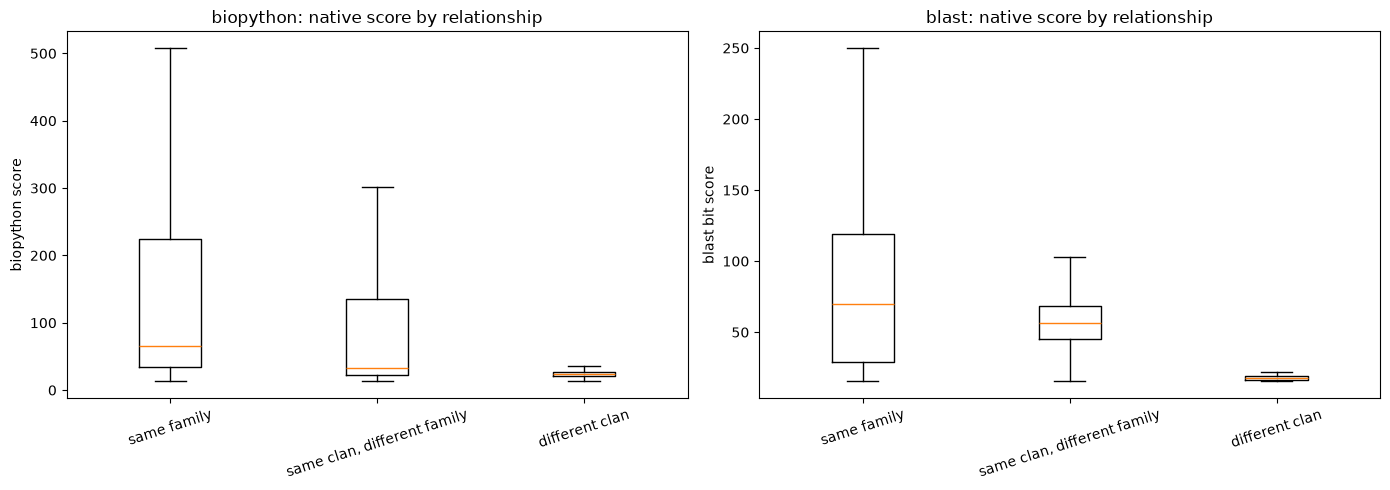

,relationship,method,pairs,reported_pairs,coverage_fraction
0,same family,biopython,3814,3814,1.000000
1,same family,blast,3814,2521,0.660986
2,"same clan, different family",biopython,3400,3400,1.000000
3,"same clan, different family",blast,3400,1612,0.474118
4,different clan,biopython,13696,13696,1.000000
5,different clan,blast,13696,465,0.033952


In [6]:
figure, axes = plt.subplots(1, len(METHOD_COLUMNS), figsize=(7 * len(METHOD_COLUMNS), 5))
axes = np.atleast_1d(axes)
for axis, (method, column) in zip(axes, METHOD_COLUMNS.items(), strict=True):
    values = [
        pair_analysis.loc[pair_analysis['relationship'] == label, column].dropna()
        for label in RELATIONSHIP_ORDER
    ]
    axis.boxplot(values, tick_labels=RELATIONSHIP_ORDER, showfliers=False)
    axis.set_title(f'{method}: native score by relationship')
    axis.set_ylabel(column.replace('_', ' '))
    axis.tick_params(axis='x', rotation=18)
figure.tight_layout()
figure.savefig(FIGURE_DIRECTORY / 'scores_by_relationship.png', dpi=180)
plt.show()

coverage_rows = []
for relationship in RELATIONSHIP_ORDER:
    group = pair_analysis.loc[pair_analysis['relationship'] == relationship]
    for method, column in METHOD_COLUMNS.items():
        coverage_rows.append({
            'relationship': relationship,
            'method': method,
            'pairs': len(group),
            'reported_pairs': int(group[column].notna().sum()),
            'coverage_fraction': group[column].notna().mean(),
        })
coverage = pd.DataFrame(coverage_rows)
display(coverage)

## A6. Treat method correlation as one diagnostic

Spearman correlation compares score rankings only on pairs reported by both
methods. It is calculated separately within each biological relationship class
so an easy same-family versus different-clan split cannot create a misleading
global correlation. Always read `comparable_pairs` alongside the coefficient;
correlation does not describe omitted BLAST pairs.


In [7]:
correlation_rows = []
scopes = [('all pairs', pair_analysis), *pair_analysis.groupby('relationship')]
for scope, group in scopes:
    for (method_a, column_a), (method_b, column_b) in combinations(
        METHOD_COLUMNS.items(), 2
    ):
        complete = group[[column_a, column_b]].dropna()
        correlation_rows.append({
            'scope': scope,
            'method_a': method_a,
            'method_b': method_b,
            'spearman_rho': complete[column_a].rank(method='average').corr(
                complete[column_b].rank(method='average')
            ),
            'comparable_pairs': len(complete),
        })
correlations = pd.DataFrame(correlation_rows)
display(correlations)

,scope,method_a,method_b,spearman_rho,comparable_pairs
0,all pairs,biopython,blast,0.997165,4598
1,different clan,biopython,blast,0.857413,465
2,"same clan, different family",biopython,blast,0.990346,1612
3,same family,biopython,blast,0.997253,2521


## A7. Define many protein collections from one scored master pool

Scoring the master pool once lets us change the input collection without recomputing alignments. The scenarios below include size-controlled diversity samples, individual clans, and individual Pfam families.

In [8]:
def diversity_ranked_ids(table, size):
    if not 1 <= size <= len(table):
        raise ValueError('collection size is outside the available range')
    ordered = table.sort_values(
        ['family_selection_rank', 'family_accession', 'node_id']
    )
    return ordered.head(size)['node_id'].tolist()


collections = {f'all_{len(metadata)}': metadata['node_id'].tolist()}
for size in BALANCED_COLLECTION_SIZES:
    if size < len(metadata):
        collections[f'diversity_{size}'] = diversity_ranked_ids(metadata, size)
for clan, group in metadata.groupby('clan_accession'):
    collections[f'clan_{clan}'] = group['node_id'].tolist()
for family, group in metadata.groupby('family_accession'):
    collections[f'family_{family}'] = group['node_id'].tolist()

collection_rows = []
for collection_id, identifiers in collections.items():
    subset = metadata.loc[metadata['node_id'].isin(identifiers)]
    collection_rows.append({
        'collection_id': collection_id,
        'proteins': len(subset),
        'possible_pairs': len(subset) * (len(subset) - 1) // 2,
        'families': subset['family_accession'].nunique(),
        'clans': subset['clan_accession'].nunique(),
    })
collection_definitions = pd.DataFrame(collection_rows).sort_values(
    ['proteins', 'collection_id'], ascending=[False, True]
)
collection_definitions.to_csv(
    SCORE_DIRECTORY / 'collection_definitions.tsv', sep='\t', index=False
)
display(collection_definitions)

,collection_id,proteins,possible_pairs,families,clans
0,all_205,205,20910,6,3
3,diversity_180,180,16110,6,3
2,diversity_120,120,7140,6,3
4,clan_CL0010,80,3160,2,1
5,clan_CL0016,77,2926,2,1
1,diversity_60,60,1770,6,3
6,clan_CL0090,48,1128,2,1
7,family_PF00018,40,780,1,1
8,family_PF00042,40,780,1,1
11,family_PF07714,40,780,1,1


## A8. Sweep graph-construction choices

`top_n` means keeping exactly the strongest `n` pairs globally; the old value 13 was only a tiny smoke test and does not scale with collection size. This notebook instead emphasises `top_k`, the union of every protein's strongest `k` available neighbours, plus percentile thresholds that retain the upper tail of each method's available scores.

In [9]:
def edge_label_fraction(graph, attribute):
    if graph.number_of_edges() == 0:
        return np.nan
    matches = sum(
        graph.nodes[a].get(attribute) == graph.nodes[b].get(attribute)
        for a, b in graph.edges
    )
    return matches / graph.number_of_edges()


graph_cache = {}
summary_rows = []
for collection_id, identifiers in collections.items():
    identifier_set = set(identifiers)
    subset_pairs = pair_scores.loc[
        pair_scores['protein_a'].isin(identifier_set)
        & pair_scores['protein_b'].isin(identifier_set)
    ]
    subset_metadata = metadata.loc[metadata['node_id'].isin(identifier_set)]
    for method, score_column in METHOD_COLUMNS.items():
        for rule, thresholds in GRAPH_RULES.items():
            for threshold in thresholds:
                graph = build_similarity_graph(
                    subset_pairs, identifiers,
                    method=method, score_column=score_column,
                    threshold=threshold, threshold_rule=rule,
                    node_metadata=subset_metadata, node_id_column='node_id',
                )
                key = (collection_id, method, rule, threshold)
                graph_cache[key] = graph
                summary = graph_summary(graph)
                component_sizes = sorted(
                    (len(component) for component in nx.connected_components(graph)),
                    reverse=True,
                )
                summary_rows.append({
                    **summary,
                    'collection_id': collection_id,
                    'score_column': score_column,
                    'largest_component': component_sizes[0],
                    'same_family_edge_fraction': edge_label_fraction(
                        graph, 'family_accession'
                    ),
                    'same_clan_edge_fraction': edge_label_fraction(
                        graph, 'clan_accession'
                    ),
                })

graph_summaries = pd.DataFrame(summary_rows)
graph_summaries.to_csv(
    SCORE_DIRECTORY / 'scenario_graph_summaries.tsv', sep='\t', index=False
)
display(graph_summaries.head())
print(f'Built {len(graph_cache)} scenario graphs in memory')

,method,threshold_rule,threshold,nodes,edges,isolates,connected_components,density,average_clustering,possible_pairs,available_pairs,available_pair_fraction,target_edges,selection_shortfall,collection_id,score_column,largest_component,same_family_edge_fraction,same_clan_edge_fraction
0,biopython,top_k,1.0,205,157,0,48,0.007508,0.000000,20910,20910,1.0,-1,0,all_205,biopython_score,10,0.974522,1.000000
1,biopython,top_k,2.0,205,298,0,7,0.014252,0.329470,20910,20910,1.0,-1,0,all_205,biopython_score,125,0.953020,0.993289
2,biopython,top_k,5.0,205,730,0,1,0.034912,0.383030,20910,20910,1.0,-1,0,all_205,biopython_score,205,0.938356,0.983562
3,biopython,top_k,10.0,205,1412,0,1,0.067527,0.415639,20910,20910,1.0,-1,0,all_205,biopython_score,205,0.881728,0.952550
4,biopython,percentile,0.9,205,2087,89,102,0.099809,0.405185,20910,20910,1.0,-1,0,all_205,biopython_score,77,0.668903,1.000000


Built 208 scenario graphs in memory


## A9. Examine size and threshold sensitivity

A conclusion at one threshold need not survive another. This code derives
density, isolates, and within-family/clan edge fractions from the graph sweep
table created in A8 and saves
`outputs/figures/pfam_clan_panel/top_k_sensitivity.png`. The plotted results are
therefore reproducible from `scenario_graph_summaries.tsv`, not copied values.


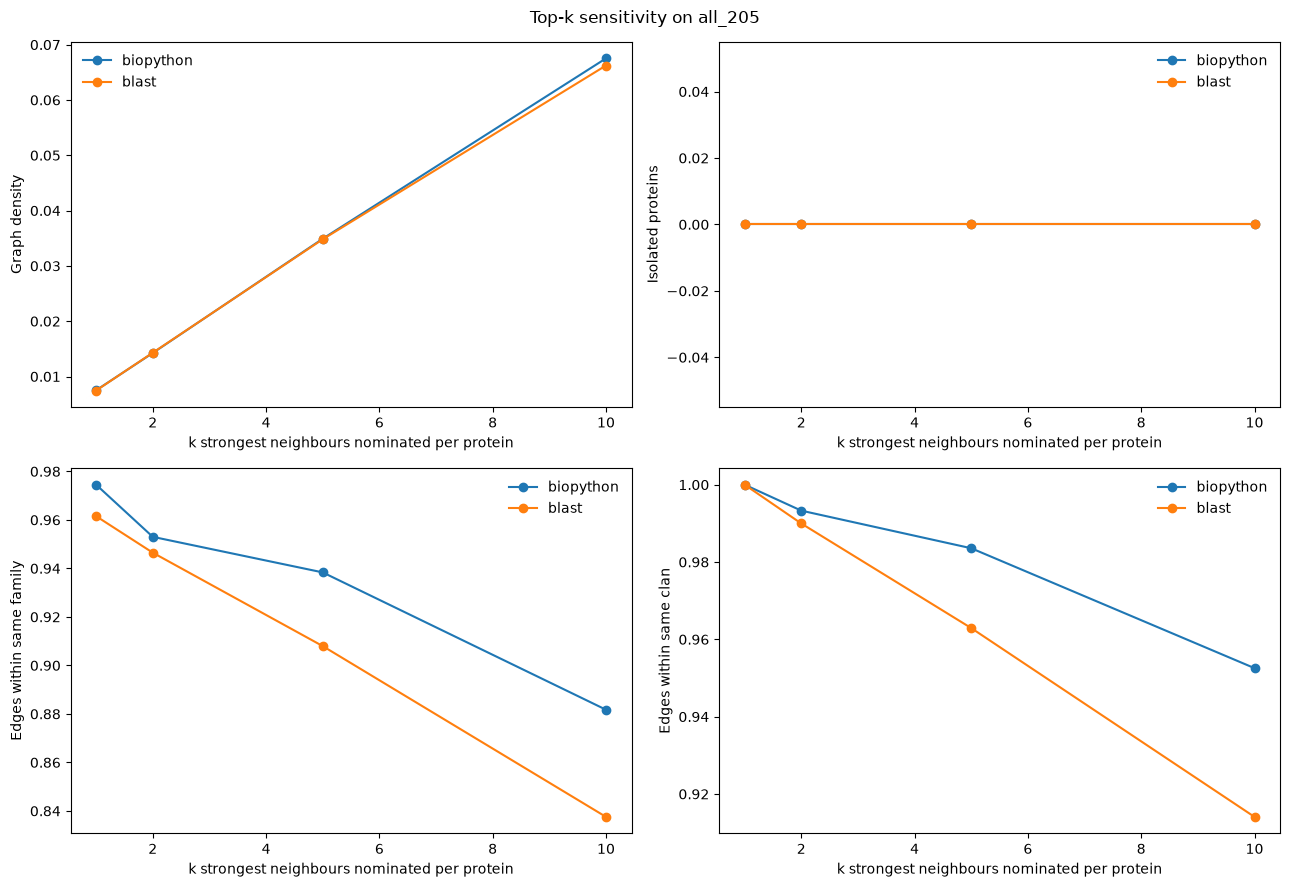

In [10]:
master_collection = f'all_{len(metadata)}'
figure, axes = plt.subplots(2, 2, figsize=(13, 9))
metrics = [
    ('density', 'Graph density'),
    ('isolates', 'Isolated proteins'),
    ('same_family_edge_fraction', 'Edges within same family'),
    ('same_clan_edge_fraction', 'Edges within same clan'),
]
top_k_summary = graph_summaries.loc[
    (graph_summaries['collection_id'] == master_collection)
    & (graph_summaries['threshold_rule'] == 'top_k')
]
for axis, (metric, label) in zip(axes.flat, metrics, strict=True):
    for method, group in top_k_summary.groupby('method'):
        axis.plot(group['threshold'], group[metric], marker='o', label=method)
    axis.set_xlabel('k strongest neighbours nominated per protein')
    axis.set_ylabel(label)
    axis.legend(frameon=False)
figure.suptitle(f'Top-k sensitivity on {master_collection}')
figure.tight_layout()
figure.savefig(FIGURE_DIRECTORY / 'top_k_sensitivity.png', dpi=180)
plt.show()

## A10. Visualise comparable graphs

Both method graphs use the same node positions, calculated from their union,
and the same Pfam-family colours. This prevents the layout algorithm from
creating an artificial visual difference. The displayed figure is also saved
under `outputs/figures/pfam_clan_panel/`; the corresponding GraphML, edge,
node, and summary files are written under `outputs/graphs/pfam_clan_panel/`.


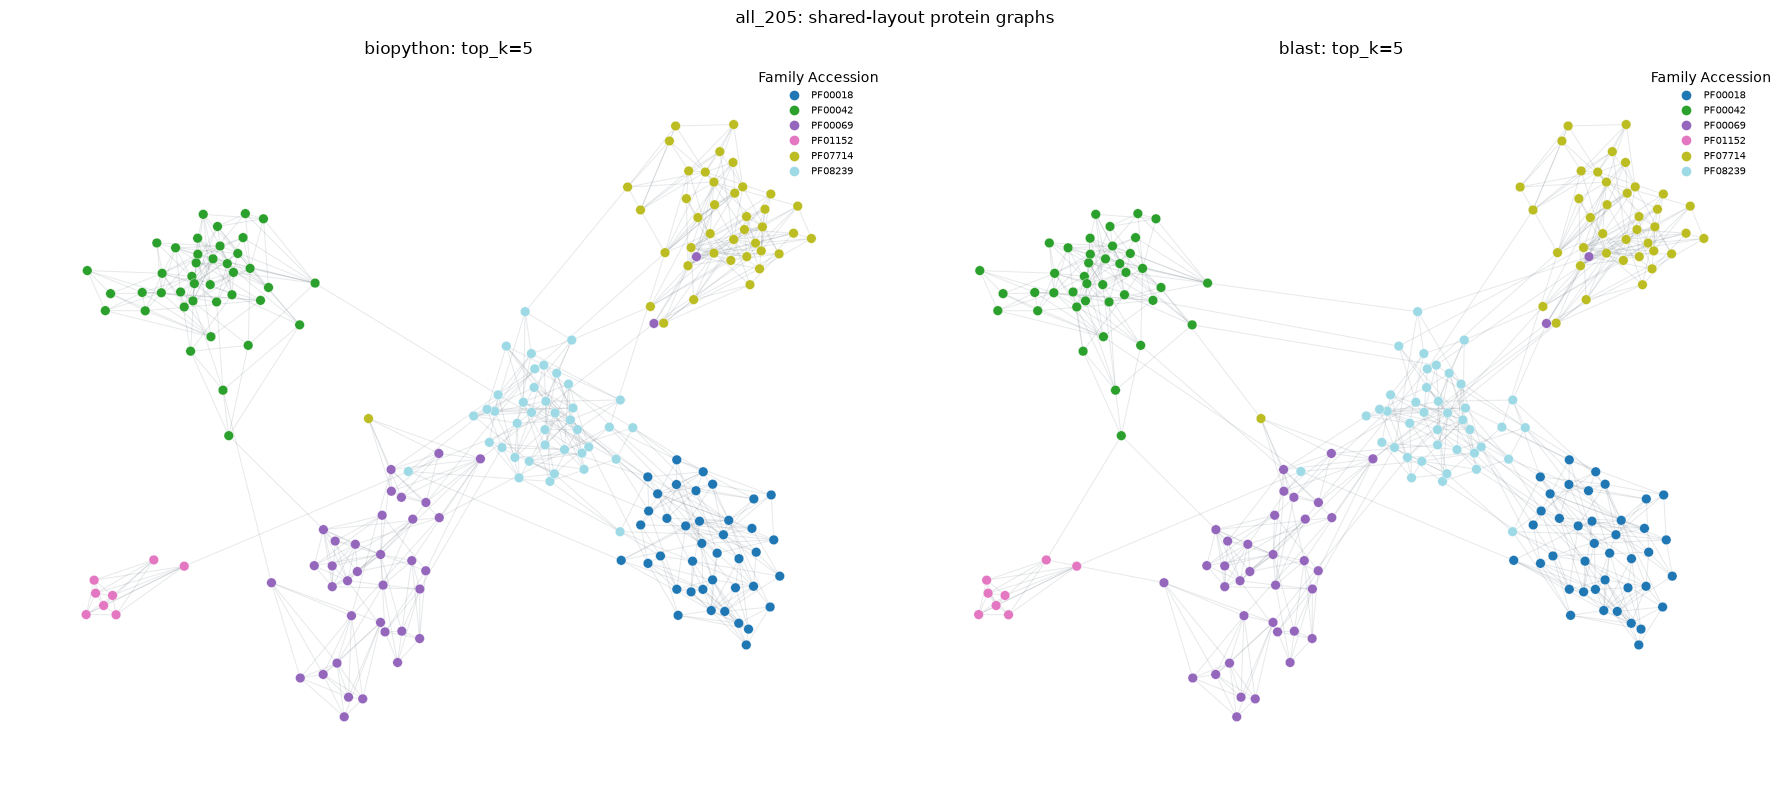

In [11]:
visual_graphs = {
    method: graph_cache[(master_collection, method, VISUAL_RULE, VISUAL_THRESHOLD)]
    for method in METHOD_COLUMNS
}
positions = shared_graph_layout(visual_graphs.values(), seed=RANDOM_SEED)
families = sorted(metadata['family_accession'].unique())
palette = plt.get_cmap('tab20', len(families))
family_colors = {family: palette(index) for index, family in enumerate(families)}
figure, axes = plt.subplots(1, len(visual_graphs), figsize=(9 * len(visual_graphs), 8))
axes = np.atleast_1d(axes)
for axis, (method, graph) in zip(axes, visual_graphs.items(), strict=True):
    draw_similarity_graph(
        graph, positions=positions, color_attribute='family_accession',
        category_colors=family_colors,
        title=f'{method}: {VISUAL_RULE}={VISUAL_THRESHOLD}',
        ax=axis, node_size=48, edge_alpha=0.16,
    )
figure.suptitle(f'{master_collection}: shared-layout protein graphs')
figure.tight_layout()
figure.savefig(
    FIGURE_DIRECTORY / f'{master_collection}_{VISUAL_RULE}_{VISUAL_THRESHOLD}.png',
    dpi=200,
)
plt.show()

for method, graph in visual_graphs.items():
    save_graph_bundle(
        graph,
        GRAPH_DIRECTORY / f'{master_collection}_{method}_{VISUAL_RULE}_{VISUAL_THRESHOLD}',
    )

## A11. Quantify method edge overlap

For every collection and graph setting, Jaccard overlap
$|E_1\cap E_2|/|E_1\cup E_2|$ measures how much of the retained edge set is
shared. The code displays the selected view and stores the complete result in
`outputs/tables/pfam_clan_panel/method_edge_overlap.tsv`.


In [12]:
def canonical_edges(graph):
    return {tuple(sorted(edge)) for edge in graph.edges}


overlap_rows = []
for collection_id in collections:
    for rule, thresholds in GRAPH_RULES.items():
        for threshold in thresholds:
            for method_a, method_b in combinations(METHOD_COLUMNS, 2):
                edges_a = canonical_edges(
                    graph_cache[(collection_id, method_a, rule, threshold)]
                )
                edges_b = canonical_edges(
                    graph_cache[(collection_id, method_b, rule, threshold)]
                )
                union = edges_a | edges_b
                overlap_rows.append({
                    'collection_id': collection_id,
                    'threshold_rule': rule,
                    'threshold': threshold,
                    'method_a': method_a, 'method_b': method_b,
                    'edges_a': len(edges_a), 'edges_b': len(edges_b),
                    'shared_edges': len(edges_a & edges_b),
                    'edge_jaccard': len(edges_a & edges_b) / len(union)
                    if union else np.nan,
                })
method_edge_overlap = pd.DataFrame(overlap_rows)
method_edge_overlap.to_csv(
    SCORE_DIRECTORY / 'method_edge_overlap.tsv', sep='\t', index=False
)
display(method_edge_overlap.loc[
    (method_edge_overlap['collection_id'] == master_collection)
    & (method_edge_overlap['threshold_rule'] == VISUAL_RULE)
])

,collection_id,threshold_rule,threshold,method_a,method_b,edges_a,edges_b,shared_edges,edge_jaccard
0,all_205,top_k,1.0,biopython,blast,157,156,128,0.691892
1,all_205,top_k,2.0,biopython,blast,298,299,255,0.745614
2,all_205,top_k,5.0,biopython,blast,730,728,612,0.723404
3,all_205,top_k,10.0,biopython,blast,1412,1385,1124,0.671847


# Part B — repeated-sampling experiment

## Scientific question

Given a balanced but otherwise unlabelled domain collection, do communities in
its sequence-similarity graph agree with Pfam family or clan labels, and which
input choices most strongly change that agreement?

Pfam labels define the balanced sampling design and are then withheld. They do
not enter pair scoring, edge selection, or Louvain community detection; they
are revealed only for evaluation.

## Predeclared factorial design

Each collection is a hierarchical draw with three design factors:

| Input factor | Predeclared levels |
|---|---|
| clans per collection | 2, 4, 8 |
| families per selected clan | 2, 3 |
| domains per selected family | 10, 20, 40 |

The Cartesian product creates the composition cells, and each cell has 50
seeded replicates. Every realised node set is reused for both scoring methods
and every graph setting, so comparisons are paired. The code in B1 calculates
the actual collection, membership, family, clan, node, and pair counts from the
saved manifests.

Graph factors are `top_k` at 1, 2, 5, and 10; score percentiles at 0.90, 0.95,
0.98, and 0.99; and target densities at 0.005, 0.01, 0.02, and 0.05. These are
design settings rather than observed results.

## Reproducibility controls

- Identical node sets are used for all method/rule comparisons within a
  collection.
- A stable hash of the base seed and full condition determines each replicate.
- Every selected family, domain, seed, parameter, and input/output checksum is
  recorded in TSV or JSON manifests.
- Raw graph evaluations are saved before summarisation. Notebook cells load
  them; empirical numbers are never maintained separately in prose.


## B1. Build and audit the sampling hierarchy

There are three distinct selection stages, and only the final stage generates
repeated collections:

1. `scripts/select_pfam_family_panel.py` reads the official Pfam catalogue,
   applies recorded eligibility criteria, seed-shuffles sorted candidates, and
   saves every acceptance or rejection.
2. `scripts/prepare_pfam_clan_panel.py` downloads the chosen seed alignments
   and deterministically selects a fixed number of diverse domain instances per
   family. This is diversity selection, not a random population sample.
3. `scripts/generate_pfam_collections.py` enumerates every predeclared
   composition and samples clans, then families within clans, then domains
   within families uniformly without replacement. Separate replicates may
   still produce the same complete node set; B6 audits that explicitly.

`collection_manifest.tsv` contains one row and seed per collection;
`collection_membership.tsv` contains the actual node membership. The cell below
loads both the fixed master panel and the generated design and computes the
realised counts.


In [13]:
LARGE_PANEL_DIRECTORY = PROJECT_ROOT / 'data/processed/pfam_large_panel'
RESAMPLING_DIRECTORY = LARGE_PANEL_DIRECTORY / 'resampling'
RECOVERY_DIRECTORY = PROJECT_ROOT / 'outputs/tables/pfam_large_panel_graph_recovery_initial'
LARGE_FIGURE_DIRECTORY = PROJECT_ROOT / 'outputs/figures/pfam_large_panel'
LARGE_FIGURE_DIRECTORY.mkdir(parents=True, exist_ok=True)

large_metadata = pd.read_csv(
    LARGE_PANEL_DIRECTORY / 'pfam_large_panel_metadata.tsv', sep='\t'
)
sampling_manifest = pd.read_csv(
    RESAMPLING_DIRECTORY / 'collection_manifest.tsv', sep='\t'
)
recovery_results = pd.read_csv(
    RECOVERY_DIRECTORY / 'graph_recovery_results.tsv', sep='\t'
)

print(
    f'{len(large_metadata)} domains; '
    f"{large_metadata['family_accession'].nunique()} families; "
    f"{large_metadata['clan_accession'].nunique()} clans; "
    f'{len(sampling_manifest)} predeclared sampled collections'
)
display(
    large_metadata.groupby(
        ['clan_accession', 'clan_name', 'family_accession', 'family_name'],
        as_index=False,
    ).agg(domains=('node_id', 'size'))
)

960 domains; 24 families; 8 clans; 900 predeclared sampled collections


,clan_accession,clan_name,family_accession,family_name,domains
0,CL0148,Viral_Gag,PF00607,gag protein p24 N-terminal domain,40
1,CL0148,Viral_Gag,PF24925,Domain of unknown function (DUF7746),40
2,CL0148,Viral_Gag,PF28884,Petuvirus genome polyprotein domain,40
3,CL0261,NUDIX,PF00293,NUDIX domain,40
4,CL0261,NUDIX,PF03559,"NDP-hexose 2,3-dehydratase",40
5,CL0261,NUDIX,PF18290,Nudix hydrolase domain,40
6,CL0342,TolB_N,PF04052,TolB amino-terminal domain,40
7,CL0342,TolB_N,PF04390,Lipopolysaccharide-assembly,40
8,CL0342,TolB_N,PF29981,Domain of unknown function (DUF8603),40
9,CL0351,CHCH,PF02297,Cytochrome oxidase c subunit VIb,40


## B2. First diagnostic slice

Slice fixes input at four clans, two families per clan, 20 domains per family:
$n = 160$, 50 sampled collections, Biopython only, $k \in \{1, 2, 5, 10\}$.
Holding input design and method fixed attributes differences across these
curves to $k$. Complete design follows in B3.

,reference_label,threshold,graphs,median_nmi,lower_quartile_nmi,upper_quartile_nmi,median_ami,median_components,median_communities
0,clan_accession,1.0,50,0.565670,0.557259,0.574221,0.476396,37.5,37.5
1,clan_accession,2.0,50,0.700440,0.683294,0.715849,0.674775,11.0,15.0
2,clan_accession,5.0,50,0.762856,0.746904,0.781213,0.750126,4.0,10.0
3,clan_accession,10.0,50,0.800000,0.800000,0.826979,0.791650,1.0,8.0
4,family_accession,1.0,50,0.739584,0.725322,0.749994,0.628850,37.5,37.5
5,family_accession,2.0,50,0.877232,0.858665,0.894176,0.855078,11.0,15.0
6,family_accession,5.0,50,0.943556,0.925227,0.959595,0.936072,4.0,10.0
7,family_accession,10.0,50,0.978104,0.956522,1.000000,0.976095,1.0,8.0


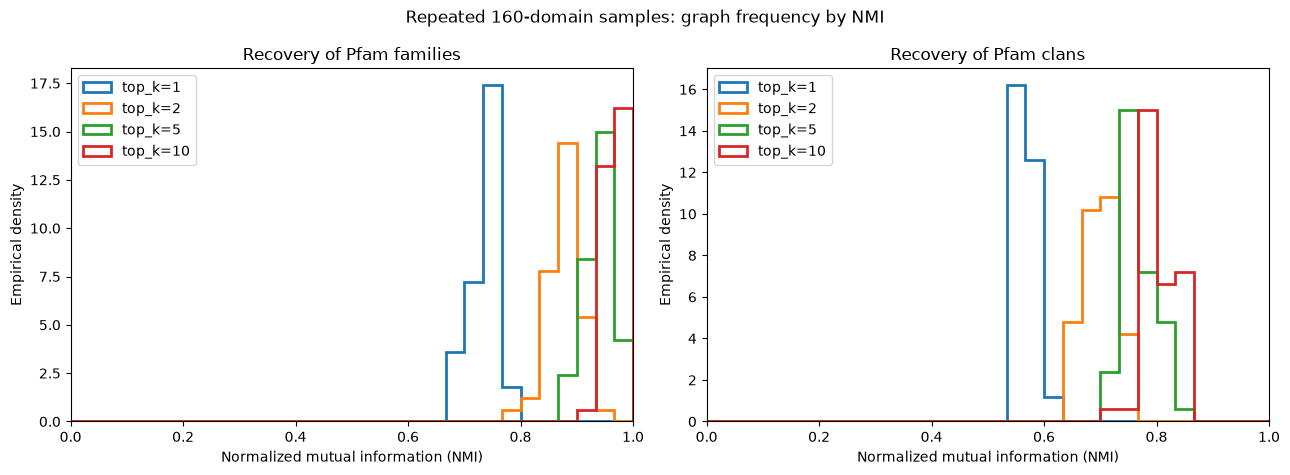

In [14]:
nmi_summary = (
    recovery_results
    .groupby(['reference_label', 'threshold'], as_index=False)
    .agg(
        graphs=('graph_id', 'nunique'),
        median_nmi=('nmi', 'median'),
        lower_quartile_nmi=('nmi', lambda values: values.quantile(0.25)),
        upper_quartile_nmi=('nmi', lambda values: values.quantile(0.75)),
        median_ami=('ami', 'median'),
        median_components=('connected_components', 'median'),
        median_communities=('inferred_community_count', 'median'),
    )
)
display(nmi_summary)

bins = np.linspace(0, 1, 31)
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8), sharex=True)
for axis, reference_label, title in zip(
    axes,
    ('family_accession', 'clan_accession'),
    ('Recovery of Pfam families', 'Recovery of Pfam clans'),
):
    subset = recovery_results.loc[
        recovery_results['reference_label'] == reference_label
    ]
    for threshold, group in subset.groupby('threshold'):
        axis.hist(
            group['nmi'], bins=bins, density=True, histtype='step',
            linewidth=2, label=f'top_k={int(threshold)}',
        )
    axis.set_title(title)
    axis.set_xlabel('Normalized mutual information (NMI)')
    axis.set_ylabel('Empirical density')
    axis.set_xlim(0, 1)
    axis.legend()
figure.suptitle('Repeated 160-domain samples: graph frequency by NMI')
figure.tight_layout()
figure.savefig(
    LARGE_FIGURE_DIRECTORY / 'initial_top_k_nmi_distributions.png', dpi=200
)
plt.show()

## B3. Load and validate the complete experiment

`scripts/run_resampled_graph_experiment.py` writes one raw row for each graph
and reference-label level to two result directories: one for `top_k` and
percentile rules, and one for matched target densities. The code below loads
both raw tables plus the summaries produced by
`scripts/summarize_resampled_graph_experiment.py`, verifies completeness, and
calculates the raw and primary-analysis sizes directly from those files.

The raw experiment remains intact for audit. Primary distributional summaries
use only composition cells whose replicate node sets are all distinct; B6
explains and displays that decision from the saved uniqueness table.

The all-pairs score manifest also records BLAST's explicit per-query target
cap and a directionality audit. The audit reduces HSPs to the strongest score
in each ordered direction, then defines relative spread as
`abs(forward - reverse) / max(forward, reverse)`.


In [15]:
FULL_RECOVERY_DIRECTORY = (
    PROJECT_ROOT / 'outputs/tables/pfam_large_panel_graph_recovery_full'
)
MATCHED_RECOVERY_DIRECTORY = (
    PROJECT_ROOT / 'outputs/tables/pfam_large_panel_graph_recovery_matched_density'
)
SUMMARY_DIRECTORY = PROJECT_ROOT / 'outputs/tables/pfam_large_panel_graph_summary'
FULL_FIGURE_DIRECTORY = PROJECT_ROOT / 'outputs/figures/pfam_large_panel_full'

full_results = pd.read_csv(
    FULL_RECOVERY_DIRECTORY / 'graph_recovery_results.tsv', sep='\t'
)
matched_results = pd.read_csv(
    MATCHED_RECOVERY_DIRECTORY / 'graph_recovery_results.tsv', sep='\t'
)
all_results = pd.concat([full_results, matched_results], ignore_index=True)

rule_summary = pd.read_csv(SUMMARY_DIRECTORY / 'rule_summary.tsv', sep='\t')
factor_summary = pd.read_csv(SUMMARY_DIRECTORY / 'factor_summary.tsv', sep='\t')
paired_method_summary = pd.read_csv(
    SUMMARY_DIRECTORY / 'paired_method_summary.tsv', sep='\t'
)
collection_uniqueness = pd.read_csv(
    SUMMARY_DIRECTORY / 'collection_uniqueness.tsv', sep='\t'
)
collection_fingerprints = pd.read_csv(
    SUMMARY_DIRECTORY / 'collection_fingerprints.tsv', sep='\t'
)
primary_collection_ids = set(
    collection_fingerprints.loc[
        collection_fingerprints['analysis_eligible'], 'collection_id'
    ]
)
primary_full_results = full_results.loc[
    full_results['collection_id'].isin(primary_collection_ids)
]
primary_matched_results = matched_results.loc[
    matched_results['collection_id'].isin(primary_collection_ids)
]
primary_results = pd.concat(
    [primary_full_results, primary_matched_results], ignore_index=True
)
score_manifest = json.loads(
    (PROJECT_ROOT / 'outputs/tables/pfam_large_panel_scores/run_manifest.json').read_text()
)

for name, table in [('full', full_results), ('matched-density', matched_results)]:
    print(
        f'{name:16s} graphs={table["graph_id"].nunique():6d}  '
        f'rows={len(table):6d}  collections={table["collection_id"].nunique():4d}  '
        f'missing NMI={int(table["nmi"].isna().sum())}  '
        f'zero-edge graphs={int((table["edges"] == 0).sum())}'
    )

primary_cell_count = int(collection_uniqueness['analysis_eligible'].sum())
primary_graph_count = pd.concat(
    [primary_full_results, primary_matched_results], ignore_index=True
)["graph_id"].nunique()
print(
    f'Primary distributional analysis: {len(primary_collection_ids)} collections, '
    f'{primary_cell_count} composition cells, {primary_graph_count:,} graphs'
)

display(
    all_results
    .groupby(['threshold_rule', 'method'], as_index=False)
    .agg(graphs=('graph_id', 'nunique'), rows=('nmi', 'size'))
)

blast_audit = score_manifest['parameters']['blast'].get('directionality_audit')
if blast_audit:
    display(pd.DataFrame([blast_audit]).rename_axis('BLAST directionality audit'))


full             graphs= 14400  rows= 28800  collections= 900  missing NMI=0  zero-edge graphs=0
matched-density  graphs=  7200  rows= 14400  collections= 900  missing NMI=0  zero-edge graphs=0
Primary distributional analysis: 700 collections, 14 composition cells, 16,800 graphs


,threshold_rule,method,graphs,rows
0,percentile,biopython,3600,7200
1,percentile,blast,3600,7200
2,target_density,biopython,3600,7200
3,target_density,blast,3600,7200
4,top_k,biopython,3600,7200
5,top_k,blast,3600,7200


,hsp_row_count,undirected_pair_count,bidirectional_pair_count,single_direction_pair_count,bidirectional_relative_spread_median,bidirectional_relative_spread_p90,bidirectional_relative_spread_max
BLAST directionality audit,,,,,,,
0,38399,19376,17744,1632,0.0,0.014922,0.614173


## B4. Test whether equal percentiles yield comparable graphs

A percentile is calculated within a method's available score set $A$. Because
BLAST omits many pairs, retaining the same upper percentile can produce a much
sparser BLAST graph than Biopython graph on identical nodes. The loaded
`rule_summary.tsv` is used below to compare realised density, edge count, NMI,
and AMI. The figure is saved as
`outputs/figures/pfam_large_panel_full/percentile_density_mismatch.png`.

Interpretation rule: a recovery difference observed together with a large
density difference cannot be attributed solely to alignment method. B5 removes
this confounding by matching the intended edge budget.


,method,threshold,median_density,median_edges,median_nmi
0,biopython,0.90,0.100000,1270.5,0.914802
1,blast,0.90,0.008316,113.0,0.668801
2,biopython,0.95,0.050139,636.5,0.884988
3,blast,0.95,0.004202,57.0,0.644321
4,biopython,0.98,0.020043,255.0,0.749409
5,blast,0.98,0.001695,23.0,0.631627
6,biopython,0.99,0.010063,128.0,0.688985
7,blast,0.99,0.000901,12.0,0.623527


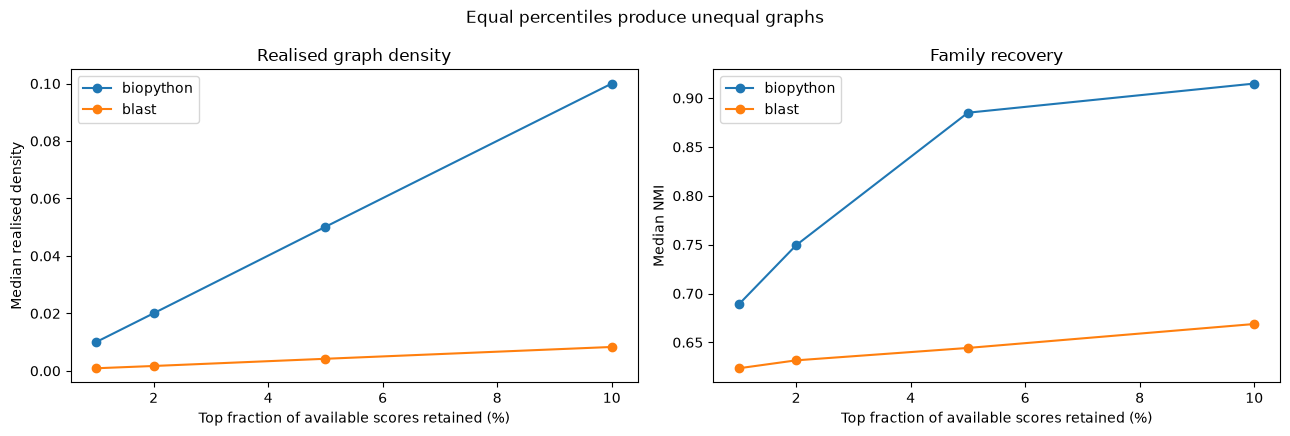

Three-panel version written by summary script: outputs/figures/pfam_large_panel_full/percentile_density_mismatch.png


In [16]:
percentile_view = rule_summary.loc[
    (rule_summary['threshold_rule'] == 'percentile')
    & (rule_summary['reference_label'] == 'family_accession')
]
display(
    percentile_view[
        ['method', 'threshold', 'median_density', 'median_edges', 'median_nmi']
    ].sort_values(['threshold', 'method'], ignore_index=True)
)

figure, axes = plt.subplots(1, 2, figsize=(13, 4.4))
for axis, column, title, ylabel in zip(
    axes,
    ('median_density', 'median_nmi'),
    ('Realised graph density', 'Family recovery'),
    ('Median realised density', 'Median NMI'),
):
    for method, group in percentile_view.groupby('method'):
        ordered = group.sort_values('threshold')
        axis.plot(
            (1 - ordered['threshold']) * 100, ordered[column],
            marker='o', label=method,
        )
    axis.set_title(title)
    axis.set_xlabel('Top fraction of available scores retained (%)')
    axis.set_ylabel(ylabel)
    axis.legend()
figure.suptitle('Equal percentiles produce unequal graphs')
figure.tight_layout()
plt.show()

figure_path = FULL_FIGURE_DIRECTORY / 'percentile_density_mismatch.png'
print(f'Three-panel version written by summary script: {figure_path.relative_to(PROJECT_ROOT)}')

## B5. Compare methods at matched edge budgets

`target_density` asks each method for the same number of strongest available
pairs on the same node set. The code loads the stored paired-method summary,
displays the absolute NMI difference at every requested density, and calculates
edge-budget shortfalls from the raw matched-density table.

A density enters the primary method comparison only if both methods can supply
the requested edge count. Settings with BLAST shortfall remain visible as a
labelled stress test. The report-facing paired plot is generated from these
stored results at
`outputs/figures/pfam_large_panel_full/matched_density_method_differences.png`.

This matches edge counts, not score scales. Louvain uses each method's native
edge weights, so differences in the *relative distribution* of retained weights
can still change communities even though multiplying every weight by one constant
would not change weighted modularity. `top_k` is a local-neighbour sensitivity
rule and its realised density is reported, but it is not called density matched.

A focused sensitivity run repeats the reference composition with Louvain
ignoring weights. Its raw results and manifest are stored under
`outputs/tables/pfam_large_panel_graph_recovery_unweighted_reference/`; the
next cell compares them with the corresponding weighted rows.


In [17]:
display(
    paired_method_summary.loc[
        paired_method_summary['reference_label'] == 'family_accession',
        ['threshold_rule', 'threshold', 'pairs', 'comparison_status',
         'median_absolute_nmi_difference', 'median_density_difference'],
    ].sort_values(['threshold_rule', 'threshold'], ignore_index=True)
)

shortfall = matched_results.loc[matched_results['selection_shortfall'] > 0]
print(
    f'{len(shortfall)} of {len(matched_results)} matched-density rows have a '
    f'non-zero edge-budget shortfall; methods affected: '
    f'{sorted(shortfall["method"].unique())}; '
    f'densities affected: {sorted(shortfall["threshold"].unique())}'
)
display(
    shortfall
    .groupby(
        ['method', 'threshold', 'clans_per_collection',
         'families_per_clan', 'domains_per_family'],
        as_index=False,
    )
    .agg(
        rows=('nmi', 'size'),
        median_target_edges=('target_edges', 'median'),
        median_actual_edges=('edges', 'median'),
        median_shortfall=('selection_shortfall', 'median'),
    )
)

# Recompute the paired difference using only graphs where matching truly held.
paired = matched_results.pivot_table(
    index=['collection_id', 'threshold', 'reference_label'],
    columns='method',
    values='nmi',
).reset_index()
affected = (
    matched_results.loc[
        matched_results['selection_shortfall'] > 0,
        ['collection_id', 'threshold'],
    ]
    .drop_duplicates()
)
affected_keys = set(map(tuple, affected.to_numpy()))
paired['has_shortfall'] = [
    (collection, threshold) in affected_keys
    for collection, threshold in zip(paired['collection_id'], paired['threshold'])
]
paired['absolute_difference'] = (paired['blast'] - paired['biopython']).abs()

shortfall_effect = []
for (reference_label, threshold), group in paired.groupby(
    ['reference_label', 'threshold']
):
    fully_matched = group.loc[~group['has_shortfall']]
    shortfall_effect.append({
        'reference_label': reference_label,
        'threshold': threshold,
        'all_pairs': len(group),
        'median_absolute_difference_all': group['absolute_difference'].median(),
        'fully_matched_pairs': len(fully_matched),
        'median_absolute_difference_matched_only':
            fully_matched['absolute_difference'].median(),
    })
display(pd.DataFrame(shortfall_effect))

UNWEIGHTED_DIRECTORY = (
    PROJECT_ROOT
    / 'outputs/tables/pfam_large_panel_graph_recovery_unweighted_reference'
)
unweighted_results = pd.read_csv(
    UNWEIGHTED_DIRECTORY / 'graph_recovery_results.tsv', sep='	'
)
weighted_reference = all_results.loc[
    (all_results['clans_per_collection'] == 4)
    & (all_results['families_per_clan'] == 2)
    & (all_results['domains_per_family'] == 20)
    & (all_results['method'].isin(['biopython', 'blast']))
    & (
        ((all_results['threshold_rule'] == 'top_k') & (all_results['threshold'] == 5))
        | (
            (all_results['threshold_rule'] == 'target_density')
            & (all_results['threshold'] == 0.02)
        )
    )
].assign(weight_treatment='native score weights')
weight_sensitivity = pd.concat(
    [
        weighted_reference,
        unweighted_results.assign(weight_treatment='unweighted edges'),
    ],
    ignore_index=True,
)
display(
    weight_sensitivity.groupby(
        ['reference_label', 'method', 'threshold_rule', 'threshold',
         'weight_treatment'],
        as_index=False,
    ).agg(
        collections=('collection_id', 'nunique'),
        median_nmi=('nmi', 'median'),
        median_ami=('ami', 'median'),
        median_communities=('inferred_community_count', 'median'),
    )
)


,threshold_rule,threshold,pairs,comparison_status,median_absolute_nmi_difference,median_density_difference
0,percentile,0.900,700,diagnostic_unmatched_available_fraction,0.236503,-0.090330
1,percentile,0.950,700,diagnostic_unmatched_available_fraction,0.212151,-0.045868
2,percentile,0.980,700,diagnostic_unmatched_available_fraction,0.110131,-0.018351
3,percentile,0.990,700,diagnostic_unmatched_available_fraction,0.055342,-0.009177
4,target_density,0.005,700,primary_matched_edge_budget,0.001073,0.000000
5,target_density,0.010,700,primary_matched_edge_budget,0.001764,0.000000
6,target_density,0.020,700,primary_matched_edge_budget,0.003396,0.000000
7,target_density,0.050,700,stress_test_edge_budget_shortfall,0.009569,0.000000
8,top_k,1.000,700,local_neighbour_rule_realised_density,0.011246,-0.000046
9,top_k,2.000,700,local_neighbour_rule_realised_density,0.018515,-0.000118


320 of 14400 matched-density rows have a non-zero edge-budget shortfall; methods affected: ['blast']; densities affected: [np.float64(0.05)]


,method,threshold,clans_per_collection,families_per_clan,domains_per_family,rows,median_target_edges,median_actual_edges,median_shortfall
0,blast,0.05,8,2,10,20,636.0,623.5,12.5
1,blast,0.05,8,3,10,100,1434.0,1147.5,286.5
2,blast,0.05,8,3,20,100,5748.0,4760.5,987.5
3,blast,0.05,8,3,40,100,23016.0,19376.0,3640.0


,reference_label,threshold,all_pairs,median_absolute_difference_all,fully_matched_pairs,median_absolute_difference_matched_only
0,clan_accession,0.005,900,0.000948,900,0.000948
1,clan_accession,0.010,900,0.001394,900,0.001394
2,clan_accession,0.020,900,0.003162,900,0.003162
3,clan_accession,0.050,900,0.008552,740,0.006442
4,family_accession,0.005,900,0.001214,900,0.001214
5,family_accession,0.010,900,0.001795,900,0.001795
6,family_accession,0.020,900,0.003791,900,0.003791
7,family_accession,0.050,900,0.008127,740,0.008293


,reference_label,method,threshold_rule,threshold,weight_treatment,collections,median_nmi,median_ami,median_communities
0,clan_accession,biopython,target_density,0.02,native score weights,50,0.524982,0.326562,87.5
1,clan_accession,biopython,target_density,0.02,unweighted edges,50,0.525410,0.326562,87.0
2,clan_accession,biopython,top_k,5.00,native score weights,50,0.762856,0.750126,10.0
3,clan_accession,biopython,top_k,5.00,unweighted edges,50,0.780557,0.769554,9.0
4,clan_accession,blast,target_density,0.02,native score weights,50,0.519804,0.320136,89.0
5,clan_accession,blast,target_density,0.02,unweighted edges,50,0.520281,0.322682,88.0
6,clan_accession,blast,top_k,5.00,native score weights,50,0.746149,0.732304,10.0
7,clan_accession,blast,top_k,5.00,unweighted edges,50,0.756577,0.743494,9.0
8,family_accession,biopython,target_density,0.02,native score weights,50,0.696036,0.476038,87.5
9,family_accession,biopython,target_density,0.02,unweighted edges,50,0.696379,0.480682,87.0


## B6. Audit independence of repeated collections

Replicates support a sampling distribution only when they represent distinct
node sets. Saturated designs that request most or all of the fixed master panel
can repeat an earlier set even though their random seeds differ.

`scripts/summarize_resampled_graph_experiment.py` hashes the sorted node IDs of
every collection, counts distinct fingerprints within each composition cell,
and writes `collection_uniqueness.tsv`. The conservative primary rule includes
an entire cell only when all declared replicates have distinct fingerprints.
The code below loads and displays the complete audit and derives the number of
excluded cells and repeated declarations.


In [18]:
display(collection_uniqueness)

degenerate = collection_uniqueness.loc[
    collection_uniqueness['duplicate_collection_count'] > 0
]
print(
    f'{len(degenerate)} of {len(collection_uniqueness)} composition cells contain '
    f'duplicate node sets; '
    f'{int(degenerate["duplicate_collection_count"].sum())} of their '
    f'{int(degenerate["declared_collections"].sum())} '
    'collection declarations repeat an earlier node set.'
)
print(
    'Fully independent cells: '
    f'{int(collection_uniqueness["analysis_eligible"].sum())}; '
    f'primary collections: {len(primary_collection_ids)}'
)

if not degenerate.empty:
    print(
        'Composition levels represented among audit-only cells — '
        f'domains/family: {sorted(degenerate["domains_per_family"].unique())}; '
        f'families/clan: {sorted(degenerate["families_per_clan"].unique())}; '
        f'clans: {sorted(degenerate["clans_per_collection"].unique())}'
    )


,clans_per_collection,families_per_clan,domains_per_family,declared_collections,unique_node_sets,duplicate_collection_count,analysis_eligible,analysis_status
0,2,2,10,50,50,0,True,primary_independent_replicates
1,2,2,20,50,50,0,True,primary_independent_replicates
2,2,2,40,50,46,4,False,audit_only_repeated_node_sets
3,2,3,10,50,50,0,True,primary_independent_replicates
4,2,3,20,50,50,0,True,primary_independent_replicates
5,2,3,40,50,23,27,False,audit_only_repeated_node_sets
6,4,2,10,50,50,0,True,primary_independent_replicates
7,4,2,20,50,50,0,True,primary_independent_replicates
8,4,2,40,50,50,0,True,primary_independent_replicates
9,4,3,10,50,50,0,True,primary_independent_replicates


4 of 18 composition cells contain duplicate node sets; 100 of their 200 collection declarations repeat an earlier node set.
Fully independent cells: 14; primary collections: 700
Composition levels represented among audit-only cells — domains/family: [np.int64(40)]; families/clan: [np.int64(2), np.int64(3)]; clans: [np.int64(2), np.int64(4), np.int64(8)]


## B7. Compare the sizes of input effects

To compare graph setting, collection composition, and alignment method on one
scale, the code first calculates median family NMI and AMI for every fixed
combination. It then varies one factor at a time while holding the others fixed
and records the range of those medians. A graph setting is the rule *and* its
parameter value. This is a descriptive effect-size comparison, not a causal
model or significance test.

The displayed table is calculated from every primary row loaded in B3,
including `top_k`, percentile, and target-density graphs. Method effects are
also shown separately for each rule family: `target_density` is the formal
matched-edge-budget comparison; `top_k` is interpreted with its realised
density; and percentile rows remain diagnostic because B4 shows their unequal
realised densities. The final two-row table is a deliberately labelled
nearby-density diagnostic for one local and one global Biopython rule; it does
not claim that their edge counts are exactly matched.


In [19]:
family_medians = (
    primary_results.loc[
        primary_results['reference_label'] == 'family_accession'
    ]
    .groupby(
        ['clans_per_collection', 'families_per_clan', 'domains_per_family',
         'method', 'threshold_rule', 'threshold'],
        as_index=False,
    )
    .agg(median_nmi=('nmi', 'median'), median_ami=('ami', 'median'))
)
composition_columns = [
    'clans_per_collection', 'families_per_clan', 'domains_per_family',
]
rule_columns = ['threshold_rule', 'threshold']


def spread_holding_fixed(table, held_fixed, metric):
    """Median and largest metric range within each held-fixed group.

    Everything not named in ``held_fixed`` is the factor being varied, so the
    range inside a group is that factor's effect at one fixed setting of the
    others.
    """
    ranges = table.groupby(held_fixed)[metric].agg(
        lambda values: values.max() - values.min()
    )
    return ranges.median(), ranges.max(), len(ranges)


effect_rows = []
for measure, metric in [('NMI', 'median_nmi'), ('AMI', 'median_ami')]:
    effects = {
        'graph setting (rule + parameter)': spread_holding_fixed(
            family_medians, composition_columns + ['method'], metric
        ),
        'collection composition': spread_holding_fixed(
            family_medians, ['method'] + rule_columns, metric
        ),
        'alignment method': spread_holding_fixed(
            family_medians, composition_columns + rule_columns, metric
        ),
    }
    for rule in ('top_k', 'percentile', 'target_density'):
        effects[f'alignment method | {rule} only'] = spread_holding_fixed(
            family_medians.loc[family_medians['threshold_rule'] == rule],
            composition_columns + rule_columns, metric,
        )
    for name, (median_spread, largest_spread, comparisons) in effects.items():
        effect_rows.append({
            'measure': measure, 'factor varied': name,
            'median spread': median_spread, 'largest spread': largest_spread,
            'comparisons': comparisons,
        })

effect_summary = pd.DataFrame(effect_rows)
display(effect_summary)

# A report-facing nearby-density diagnostic; this is not called exact matching.
nearby_density_rule_comparison = rule_summary.loc[
    (rule_summary['reference_label'] == 'family_accession')
    & (rule_summary['method'] == 'biopython')
    & (
        ((rule_summary['threshold_rule'] == 'top_k') & (rule_summary['threshold'] == 5))
        | (
            (rule_summary['threshold_rule'] == 'target_density')
            & (rule_summary['threshold'] == 0.05)
        )
    ),
    ['threshold_rule', 'threshold', 'graphs', 'median_density',
     'median_nmi', 'median_ami'],
]
display(nearby_density_rule_comparison)


,measure,factor varied,median spread,largest spread,comparisons
0,NMI,graph setting (rule + parameter),0.325200,0.462976,28
1,NMI,collection composition,0.246795,0.372394,24
2,NMI,alignment method,0.014467,0.393382,168
3,NMI,alignment method | top_k only,0.014085,0.082736,56
4,NMI,alignment method | percentile only,0.140010,0.393382,56
5,NMI,alignment method | target_density only,0.001657,0.034545,56
6,AMI,graph setting (rule + parameter),0.858752,0.910284,28
7,AMI,collection composition,0.240876,0.622373,24
8,AMI,alignment method,0.019850,0.797948,168
9,AMI,alignment method | top_k only,0.019664,0.096033,56


,threshold_rule,threshold,graphs,median_density,median_nmi,median_ami
31,target_density,0.05,700,0.050000,0.886441,0.852915
34,top_k,5.00,700,0.041824,0.948931,0.938142


## B8. Load the report-facing distribution figures

All figures in this section are generated by
`scripts/summarize_resampled_graph_experiment.py` from saved raw graph results.
The reference composition is selected by script arguments rather than hidden
inside the notebook.

1. The two rule-frequency figures report the empirical percentage of repeated
   collections in common NMI or AMI bins for both methods and both label levels.
2. The composition sweep separates primary cells from audit-only saturated
   cells.
3. The NMI-versus-AMI figure reveals when fragmentation inflates unadjusted
   agreement. AMI is primary for comparisons across compositions; NMI remains
   secondary for readability.

4. A deterministic score-permutation control preserves each selected node set
   and its score distribution but shuffles scores among pair identities before
   graph construction. It therefore measures recovery after sequence-pair signal
   is destroyed; it is a computational negative control, not a new biological
   population.

The code displays the saved PNGs, then loads the stored null results and compares
them with the matching real graphs.


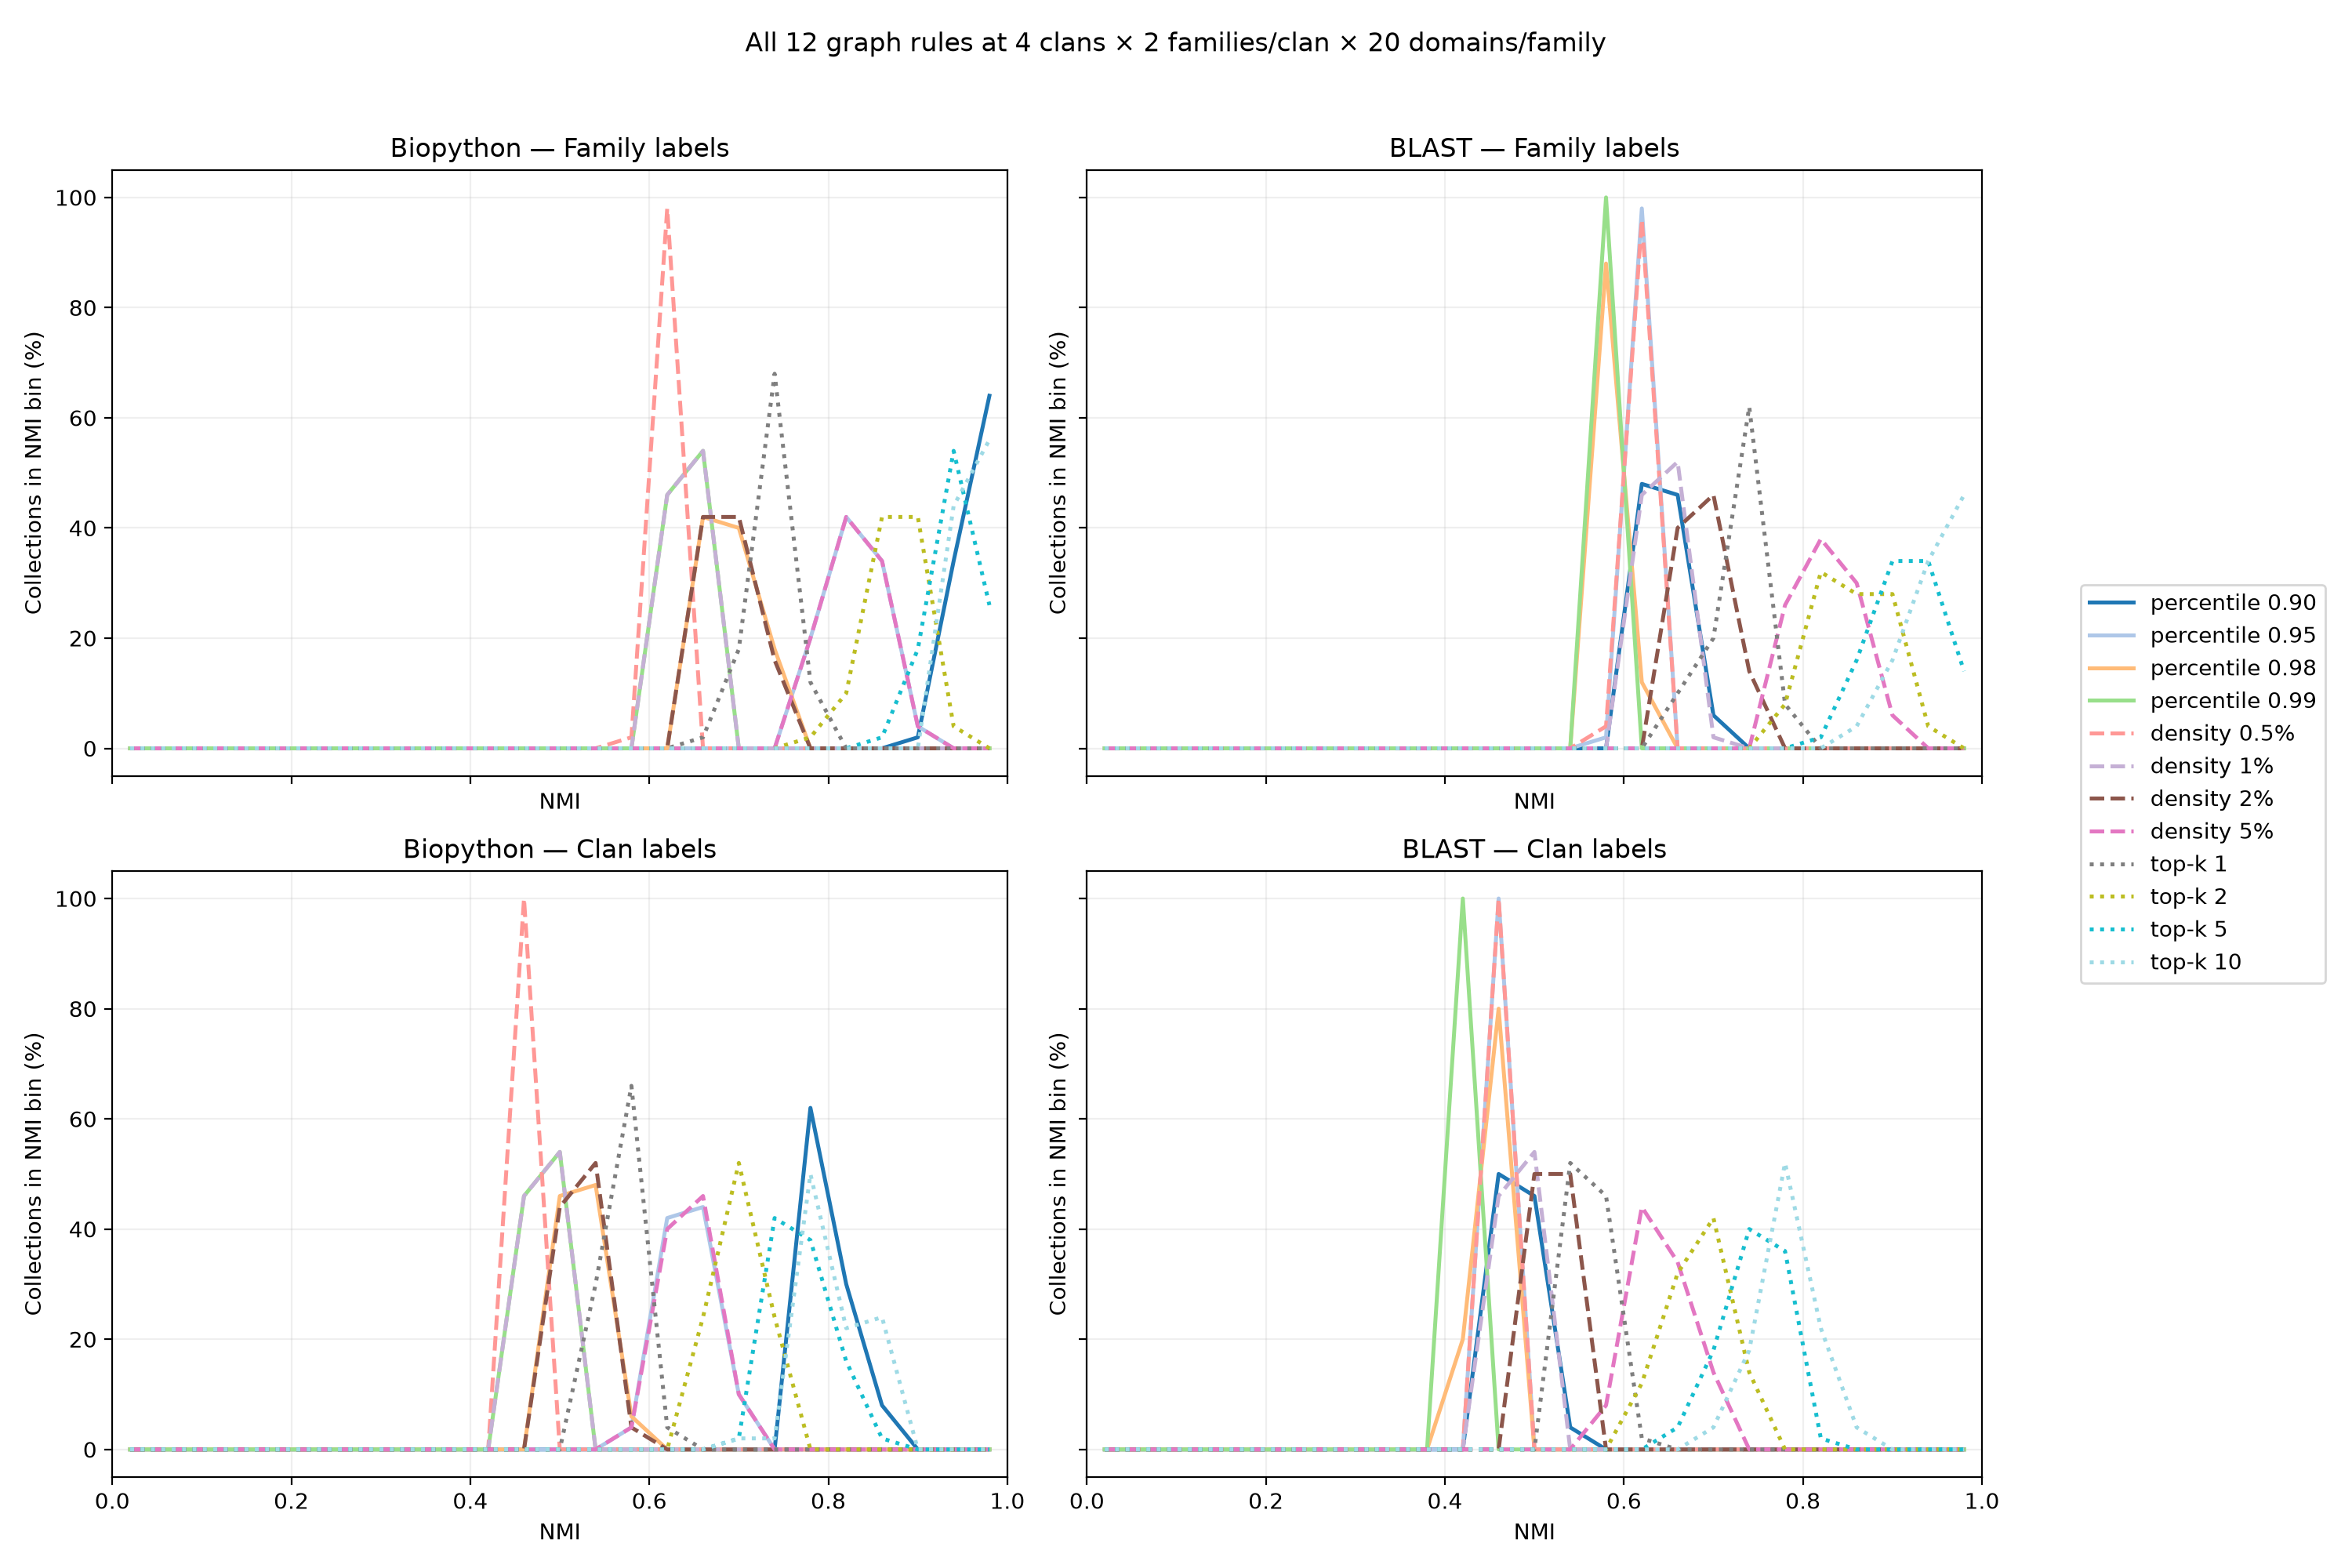

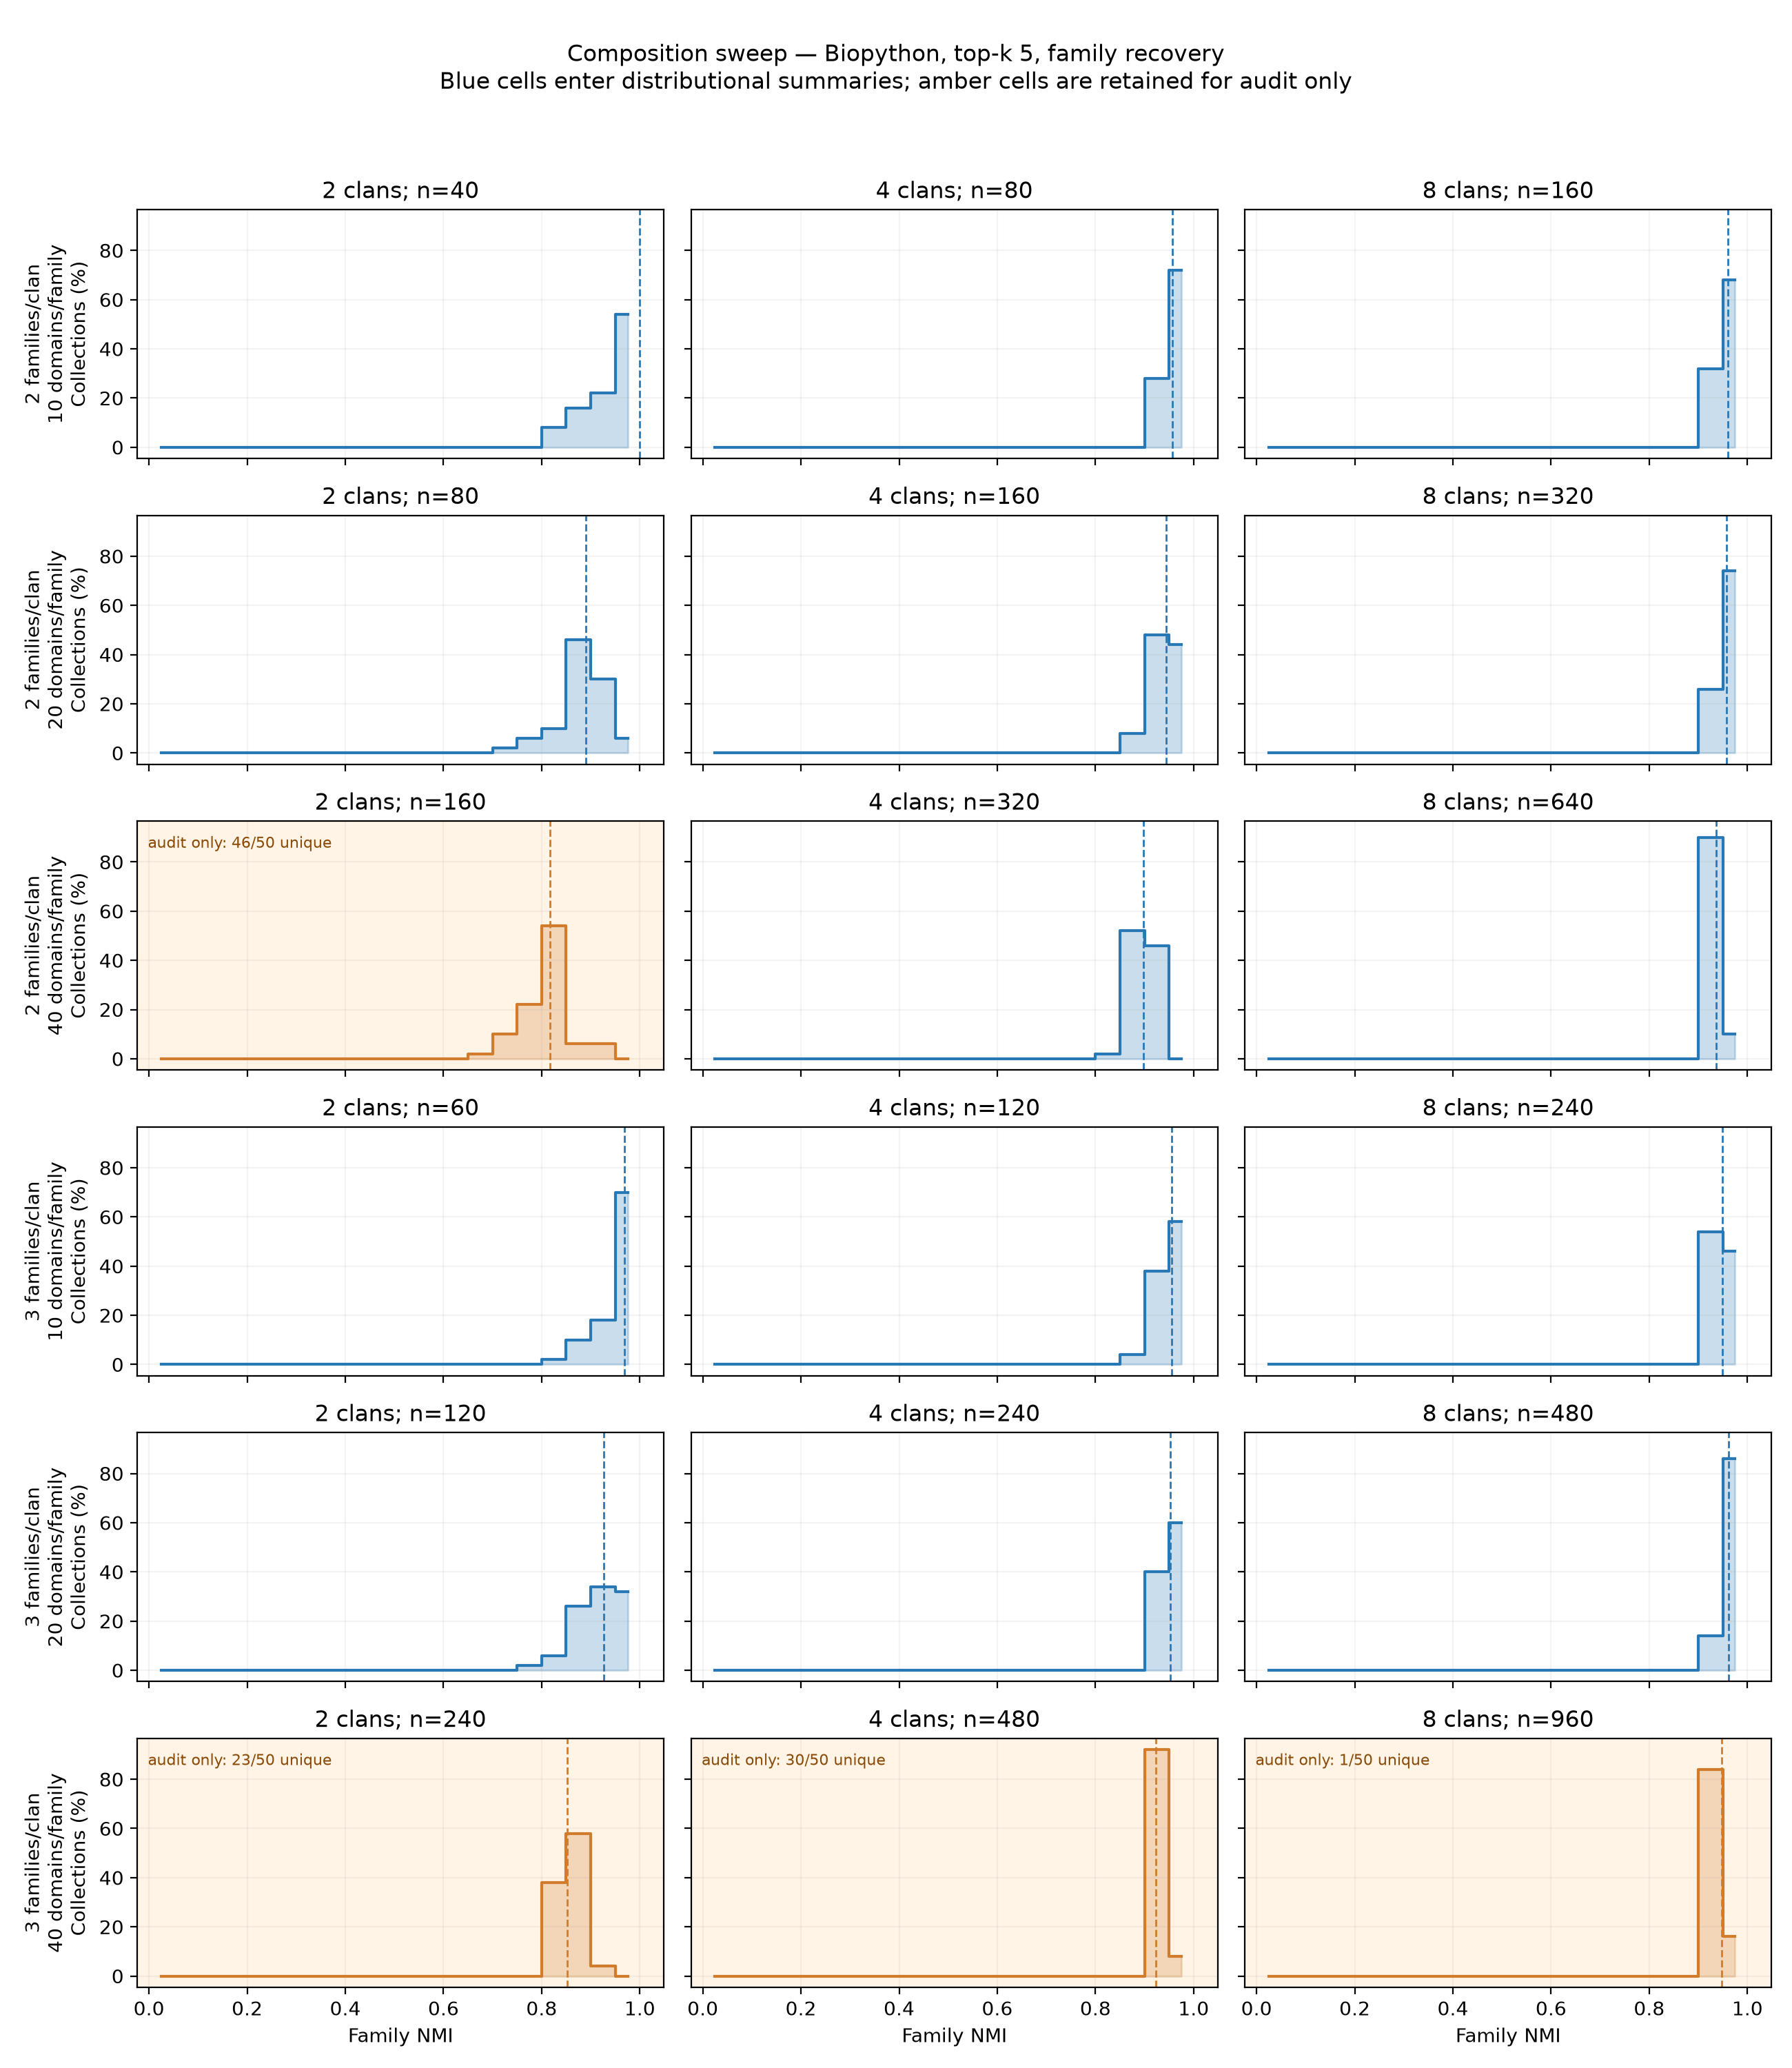

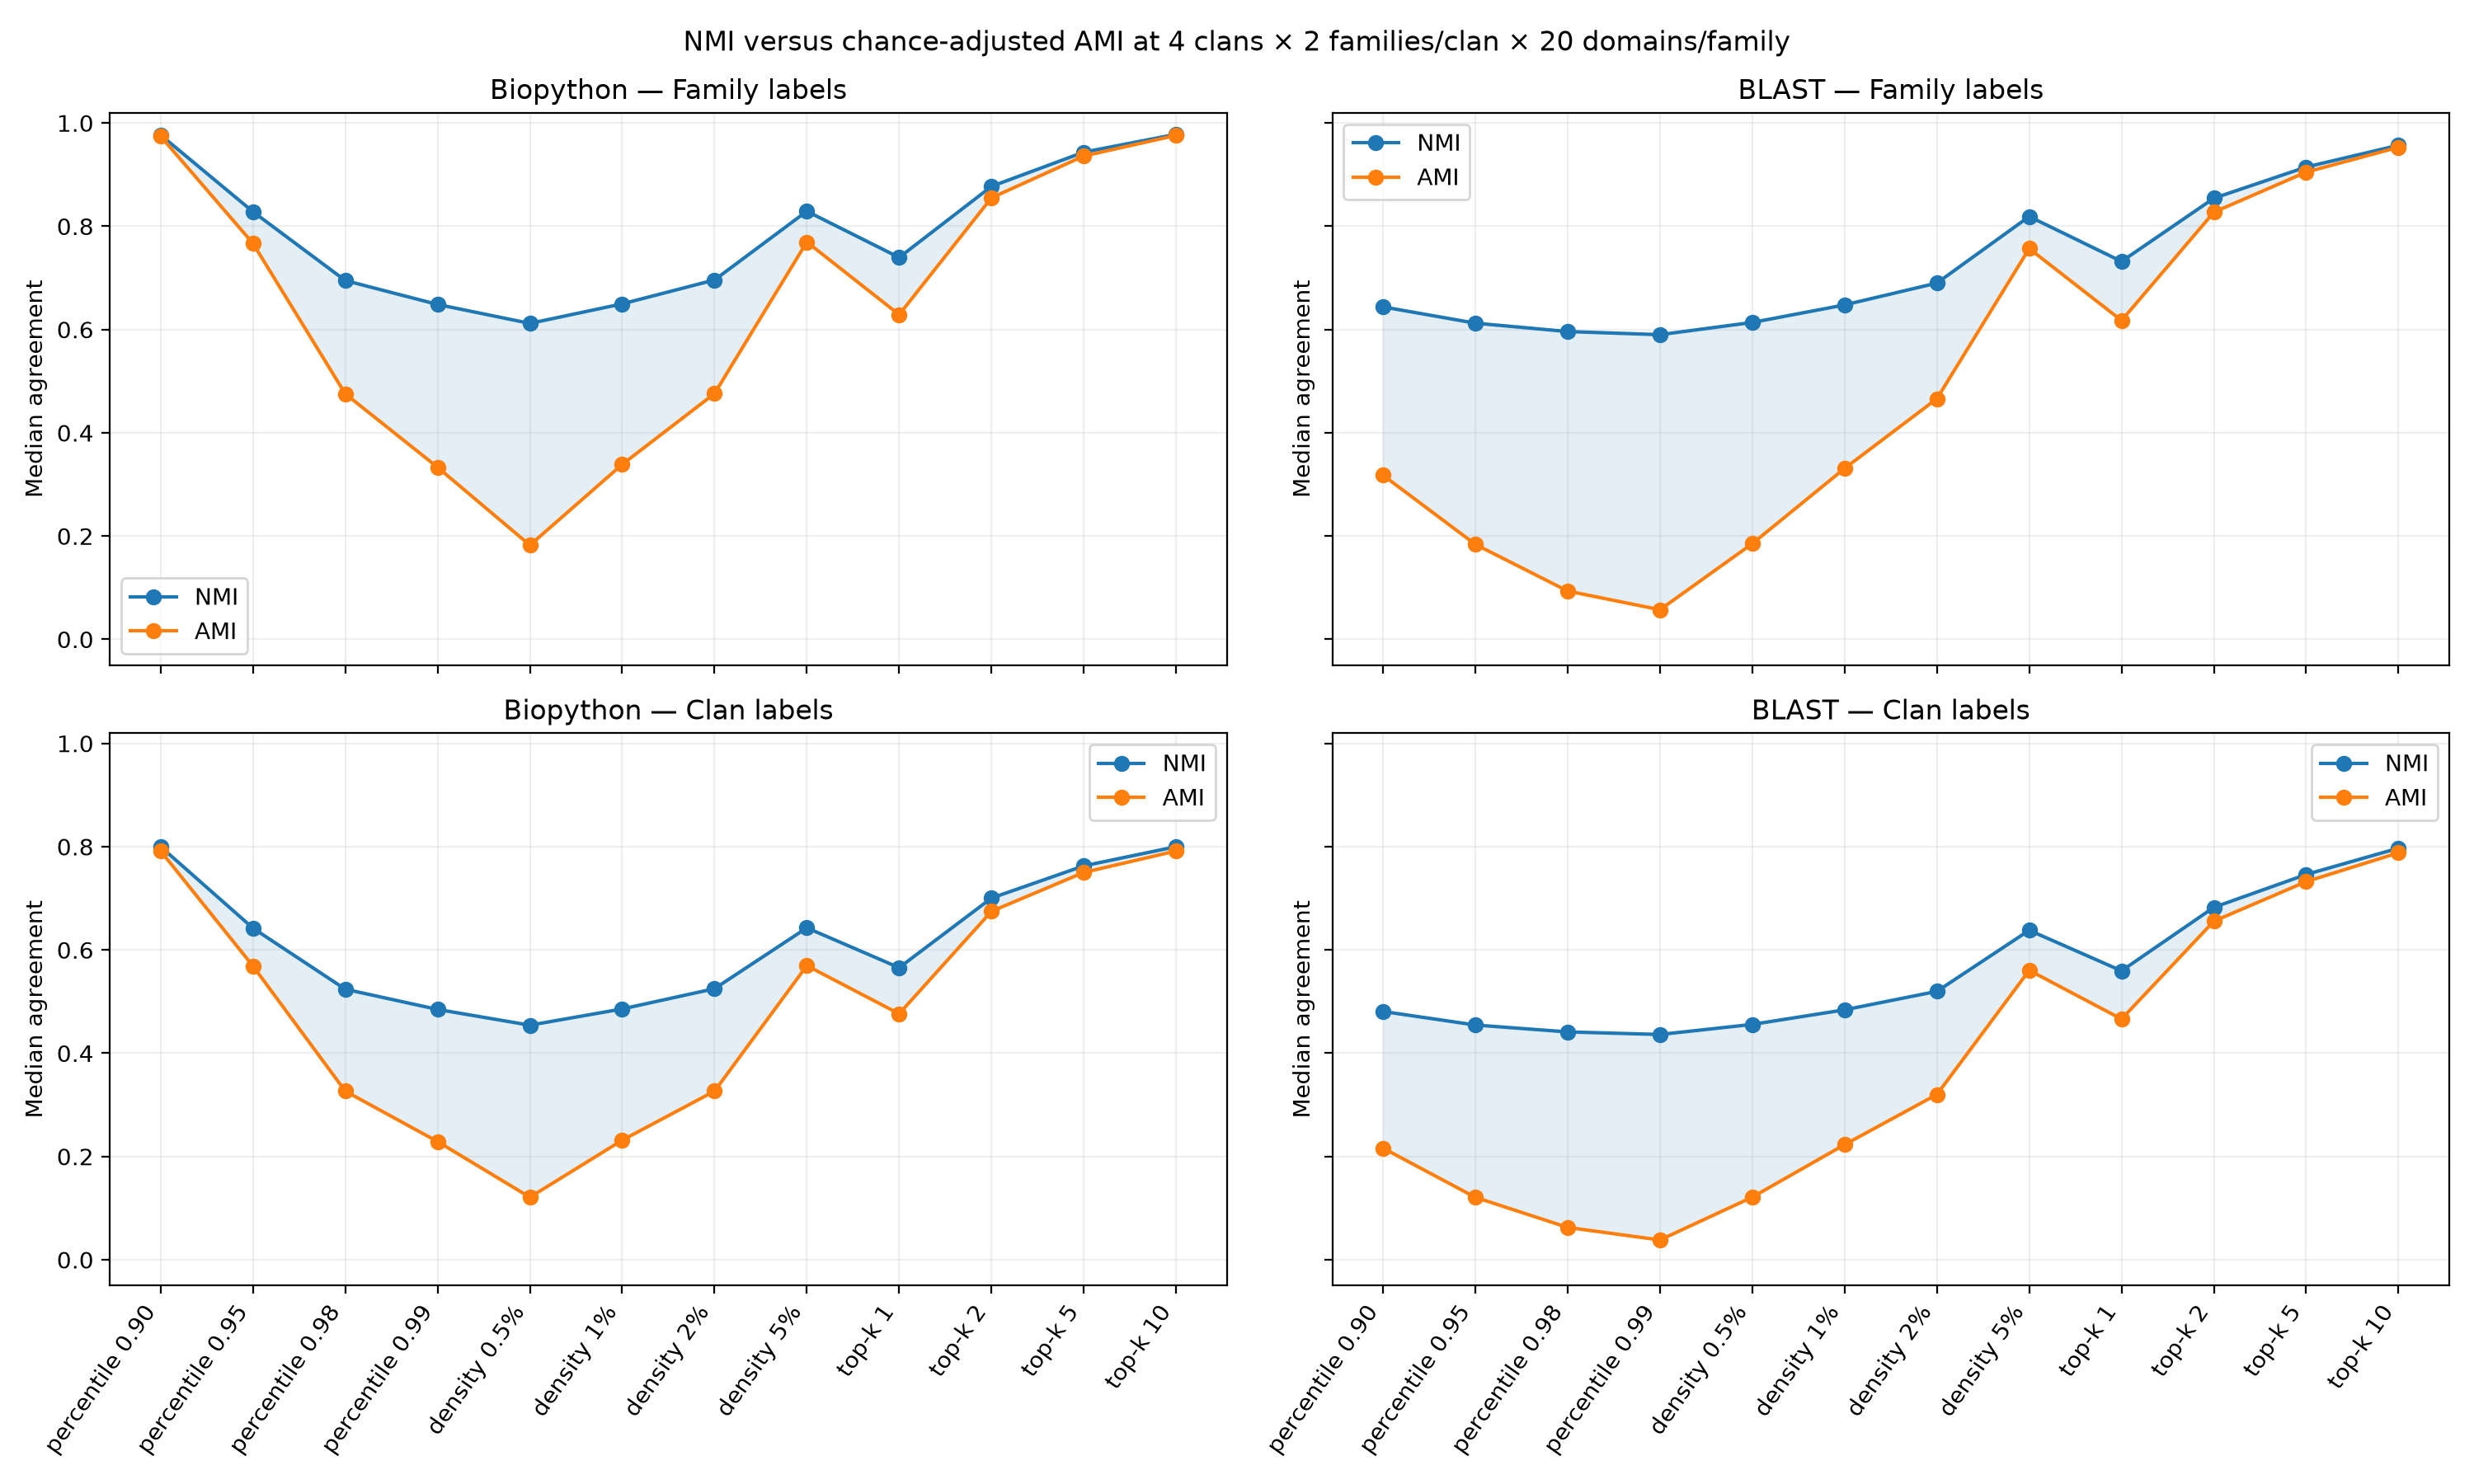

,reference_label,threshold_rule,threshold,score_treatment,collections,median_nmi,median_ami,median_communities
0,clan_accession,target_density,0.02,observed pair scores,20,0.505892,0.293941,90.5
1,clan_accession,target_density,0.02,scores permuted among pairs,20,0.085654,-0.001302,18.0
2,clan_accession,top_k,5.00,observed pair scores,20,0.762036,0.749299,10.0
3,clan_accession,top_k,5.00,scores permuted among pairs,20,0.056863,0.002694,10.5
4,family_accession,target_density,0.02,observed pair scores,20,0.673641,0.425391,90.5
5,family_accession,target_density,0.02,scores permuted among pairs,20,0.163112,-0.003715,18.0
6,family_accession,top_k,5.00,observed pair scores,20,0.952294,0.946619,10.0
7,family_accession,top_k,5.00,scores permuted among pairs,20,0.123954,0.009322,10.5


In [20]:
for filename in [
    'rule_nmi_frequency_c4_f2_d20.png',
    'rule_ami_frequency_c4_f2_d20.png',
    'composition_sweep_biopython_top_k_5_family.png',
    'nmi_vs_ami_by_rule.png',
]:
    display(Image(filename=FULL_FIGURE_DIRECTORY / filename))

NULL_DIRECTORY = PROJECT_ROOT / 'outputs/tables/pfam_large_panel_score_permutation_null'
null_results = pd.read_csv(NULL_DIRECTORY / 'graph_recovery_results.tsv', sep='	')
null_manifest = json.loads((NULL_DIRECTORY / 'run_manifest.json').read_text())
null_collection_ids = set(null_results['collection_id'])
real_for_null = primary_results.loc[
    (primary_results['collection_id'].isin(null_collection_ids))
    & (primary_results['method'] == null_manifest['method'])
    & (
        ((primary_results['threshold_rule'] == 'top_k') & (primary_results['threshold'] == 5))
        | (
            (primary_results['threshold_rule'] == 'target_density')
            & (primary_results['threshold'] == 0.02)
        )
    )
].assign(score_treatment='observed pair scores')
null_comparison = pd.concat(
    [
        real_for_null,
        null_results.assign(score_treatment='scores permuted among pairs'),
    ],
    ignore_index=True,
)
display(
    null_comparison.groupby(
        ['reference_label', 'threshold_rule', 'threshold', 'score_treatment'],
        as_index=False,
    ).agg(
        collections=('collection_id', 'nunique'),
        median_nmi=('nmi', 'median'),
        median_ami=('ami', 'median'),
        median_communities=('inferred_community_count', 'median'),
    )
)


In [21]:
# Derive a compact, traceable results table from the artifacts loaded above.
family_effects = effect_summary.loc[
    effect_summary["factor varied"].isin(
        [
            "graph setting (rule + parameter)",
            "collection composition",
            "alignment method | top_k only",
            "alignment method | percentile only",
            "alignment method | target_density only",
        ]
    )
]
fully_matched_family = paired_method_summary.loc[
    (paired_method_summary["reference_label"] == "family_accession")
    & (paired_method_summary["threshold_rule"] == "target_density")
    & (paired_method_summary["comparison_status"] == "primary_matched_edge_budget")
]
percentile_family = paired_method_summary.loc[
    (paired_method_summary["reference_label"] == "family_accession")
    & (paired_method_summary["threshold_rule"] == "percentile")
]

headline_results = pd.concat(
    [
        pd.DataFrame(
            [
                {
                    "result": "Raw graphs evaluated",
                    "value": all_results["graph_id"].nunique(),
                    "source": "two graph_recovery_results.tsv files",
                },
                {
                    "result": "Primary graphs after uniqueness audit",
                    "value": primary_results["graph_id"].nunique(),
                    "source": "collection_uniqueness.tsv + raw result tables",
                },
                {
                    "result": "Primary sampled collections",
                    "value": len(primary_collection_ids),
                    "source": "collection_fingerprints.tsv",
                },
            ]
        ),
        family_effects.rename(
            columns={"factor varied": "result", "median spread": "value"}
        ).assign(
            result=lambda table: (
                "Median family-" + table["measure"] + " range: " + table["result"]
            ),
            source="B7 calculation from primary raw results",
        )[["result", "value", "source"]],
        fully_matched_family.assign(
            result=lambda table: (
                "Median absolute family-NMI method difference at density "
                + table["threshold"].astype(str)
            ),
            value=lambda table: table["median_absolute_nmi_difference"],
            source="paired_method_summary.tsv",
        )[["result", "value", "source"]],
        percentile_family.assign(
            result=lambda table: (
                "Median absolute family-NMI method difference at percentile "
                + table["threshold"].astype(str)
            ),
            value=lambda table: table["median_absolute_nmi_difference"],
            source="paired_method_summary.tsv",
        )[["result", "value", "source"]],
    ],
    ignore_index=True,
)
count_results = {
    'Raw graphs evaluated',
    'Primary graphs after uniqueness audit',
    'Primary sampled collections',
}
headline_display = headline_results.copy()
headline_display['value'] = [
    f'{int(value):,}' if result in count_results else f'{value:.4f}'
    for result, value in zip(headline_display['result'], headline_display['value'])
]
display(headline_display)


,result,value,source
0,Raw graphs evaluated,"21,600",two graph_recovery_results.tsv files
1,Primary graphs after uniqueness audit,"16,800",collection_uniqueness.tsv + raw result tables
2,Primary sampled collections,700,collection_fingerprints.tsv
3,Median family-NMI range: graph setting (rule +...,0.3252,B7 calculation from primary raw results
4,Median family-NMI range: collection composition,0.2468,B7 calculation from primary raw results
5,Median family-NMI range: alignment method | to...,0.0141,B7 calculation from primary raw results
6,Median family-NMI range: alignment method | pe...,0.1400,B7 calculation from primary raw results
7,Median family-NMI range: alignment method | ta...,0.0017,B7 calculation from primary raw results
8,Median family-AMI range: graph setting (rule +...,0.8588,B7 calculation from primary raw results
9,Median family-AMI range: collection composition,0.2409,B7 calculation from primary raw results


## Conclusions, limitations, and result provenance

### Interpretation of the computed results

The dynamically generated tables and figures above support four conclusions.
First, sequence-similarity graphs recover the withheld Pfam hierarchy, with
family structure generally clearer than the broader clan structure. Second,
recovery changes materially with collection composition and edge rule, so no
single threshold should be presented as universally correct. Third, the large
method difference seen under equal score percentiles largely reflects unequal
graph density caused by BLAST no-hits; it becomes much smaller when the edge
budget is genuinely matched. Fourth, AMI is safer than NMI for cross-composition claims because sparse
fragmentation can create apparent unadjusted agreement. Fifth, the stored
score-permutation control removes the apparent recovery in AMI when pairwise
sequence signal is destroyed, while NMI retains a positive chance floor. Sixth,
the focused unweighted rerun preserves the main qualitative patterns, so they
are not solely an artefact of the methods' native score scales. Finally, the
nearby-density diagnostic makes the promising recovery of the local `top_k`
rule visible, while explicitly stopping short of an exact edge-matched rule
claim.

These conclusions are intentionally qualitative here. Their numerical support
is always the output of a code cell that reads a stored artifact, especially
the `headline_results` table immediately above.

### Authoritative result map

| Stage | Stored artifact loaded by this notebook | Producing implementation |
|---|---|---|
| Master-family eligibility and rejections | `data/processed/pfam_sampling_frame/family_selection_trace.tsv` and `selection_manifest.json` | `scripts/select_pfam_family_panel.py` |
| Master domain panel | `data/processed/pfam_large_panel/pfam_large_panel_metadata.tsv`, FASTA, and manifest | `scripts/prepare_pfam_clan_panel.py` |
| Repeated collection definitions | `data/processed/pfam_large_panel/resampling/collection_manifest.tsv`, `collection_membership.tsv`, and `experiment_manifest.json` | `scripts/generate_pfam_collections.py` and `src/.../sampling.py` |
| All-pairs method scores | `outputs/tables/pfam_large_panel_scores/paired_scores.tsv` and `run_manifest.json` | `scripts/run_pair_scores.py` and scoring modules under `src/` |
| Raw graph/community evaluations | `outputs/tables/pfam_large_panel_graph_recovery_full/graph_recovery_results.tsv` and the matched-density counterpart | `scripts/run_resampled_graph_experiment.py`, `src/.../graphs.py`, and `src/.../evaluation.py` |
| Unweighted community sensitivity | `outputs/tables/pfam_large_panel_graph_recovery_unweighted_reference/graph_recovery_results.tsv` and manifest | `scripts/run_resampled_graph_experiment.py --unweighted-communities` |
| Score-permutation negative control | `outputs/tables/pfam_large_panel_score_permutation_null/graph_recovery_results.tsv` and manifest | `scripts/run_score_permutation_null.py` |
| Independence audit and summary tables | `outputs/tables/pfam_large_panel_graph_summary/*.tsv` and `summary_manifest.json` | `scripts/summarize_resampled_graph_experiment.py` |
| Report-facing figures | `outputs/figures/pfam_large_panel_full/*.png` | same summarisation script |

The JSON manifests record parameters, versions, timestamps, checksums, and the
generator responsible for each output. The raw graph result tables remain the
source of truth; summaries and figures are reproducible derivatives.

### Boundaries of the claim

- Nodes are curated Pfam seed-domain instances, not full-length proteins and
  not a uniform sample of all protein biology.
- DEDAL is demonstrated only in the pilot; the scaled comparison concerns
  Biopython and BLAST.
- The score-permutation run is a computational negative control for pair-score
  signal. It is not a biological negative-control dataset or evidence of
  generalisation beyond the selected Pfam panel.
- Domain representatives were diversity-selected from curated Pfam seeds, so
  the master panel is not a prevalence-weighted population sample.
- Saturated composition cells remain available for audit but do not enter the
  primary repeated-sample distributions; B6 computes which factor levels this
  exclusion affects, so the primary factorial design is acknowledged as
  unbalanced at those levels.
- A target density with insufficient BLAST coverage is a stress test, not a
  fully matched method comparison. Matching an edge budget also does not match
  the methods' relative edge-weight distributions.

Further biological controls, complete-protein collections, synthetic known-tree
data, and additional structural graph statistics are future work rather than
requirements for the present report.

## References

Canonical BibTeX metadata is stored in `references/references.bib`. Key sources
used directly in this notebook are:

- Smith and Waterman (1981), local sequence alignment,
  `smith1981identification`.
- Gotoh (1982), affine-gap dynamic programming, `gotoh1982improved`.
- Henikoff and Henikoff (1992), BLOSUM substitution matrices,
  `henikoff1992amino`.
- Cock et al. (2009), Biopython, `cock2009biopython`.
- Camacho et al. (2009), BLAST+, `camacho2009blastplus`; Karlin and Altschul
  (1990) and Altschul et al. (1990), BLAST score statistics and bit scores,
  `karlin1990methods` and `altschul1990basic`.
- Llinares-López et al. (2023), DEDAL, `llinareslopez2023deep`.
- Mistry et al. (2021), Pfam, `mistry2021pfam`.
- Atkinson et al. (2009) and Gerlt et al. (2015), sequence-similarity networks,
  `atkinson2009sequence` and `gerlt2015efi`.
- Apeltsin et al. (2011) and Hornung and Terrapon (2023), graph-threshold
  sensitivity, `apeltsin2011threshold` and `hornung2023objective`.
- Blondel et al. (2008), Louvain community detection, `blondel2008fast`;
  Hagberg et al. (2008), NetworkX, `hagberg2008exploring`.
- Vinh, Epps, and Bailey (2010), NMI/AMI and chance correction,
  `vinh2010information`; Pedregosa et al. (2011), the scikit-learn metric
  implementation, `pedregosa2011scikitlearn`.
